---
numbering: false
---

# 1.4: Vectors and vector arithmetic

We now have the foundation we needed to introduce the concept of a vector. Everything we do for the remainder of the course will build upon this section.

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path as _PlotPath
import sys as _plot_sys

_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly


def _vector_figure(vectors, vdeltax=0.3, vdeltay=0.3, vdeltaz=0.3):
    dimension = len(vectors[0][0][0])
    fig = go.Figure()

    for (start, end), color, label in vectors:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        delta = end - start

        if dimension == 2:
            fig.add_trace(go.Scatter(
                x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
                line=dict(color=color, width=4), showlegend=False,
                hovertemplate="(%{x}, %{y})<extra></extra>",
            ))
            fig.add_annotation(
                x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
                arrowcolor=color,
            )
            if label:
                midpoint = (start + end) / 2
                fig.add_annotation(
                    x=midpoint[0] + vdeltax, y=midpoint[1] + vdeltay,
                    text=label, showarrow=False, font=dict(color=color, size=16),
                )
        else:
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines", line=dict(color=color, width=8),
                showlegend=False, hoverinfo="skip",
            ))
            length = np.linalg.norm(delta)
            if length:
                unit = delta / length
                fig.add_trace(go.Cone(
                    x=[end[0]], y=[end[1]], z=[end[2]],
                    u=[unit[0]], v=[unit[1]], w=[unit[2]],
                    anchor="tip", sizemode="absolute", sizeref=0.28,
                    colorscale=[[0, color], [1, color]], showscale=False,
                    hoverinfo="skip",
                ))
            if label:
                midpoint = (start + end) / 2
                fig.add_trace(go.Scatter3d(
                    x=[midpoint[0] + vdeltax], y=[midpoint[1] + vdeltay],
                    z=[midpoint[2] + vdeltaz], mode="text", text=[label],
                    textfont=dict(color=color, size=16), hoverinfo="skip",
                    showlegend=False,
                ))

    return fig


def plot_vectors_non_origin(vectors, **kwargs):
    return _vector_figure(vectors, **kwargs)


def plot_vectors(vectors, **kwargs):
    converted = []
    for endpoint, color, label in vectors:
        converted.append(((tuple(0 for _ in endpoint), endpoint), color, label))
    return _vector_figure(converted, **kwargs)


def _set_vector_colors(fig, vectors, overrides):
    if np.asarray(vectors[0][0]).ndim == 1:
        vectors = [((tuple(0 for _ in endpoint), endpoint), color, label) for endpoint, color, label in vectors]
    dimension = len(vectors[0][0][0])
    trace_index = 0
    annotation_index = 0

    for vector_index, ((start, end), _, label) in enumerate(vectors):
        color = overrides.get(vector_index)
        if dimension == 2:
            if color:
                fig.data[trace_index].line.color = color
                fig.layout.annotations[annotation_index].arrowcolor = color
                if label:
                    fig.layout.annotations[annotation_index + 1].font.color = color
            trace_index += 1
            annotation_index += 1 + bool(label)
        else:
            if color:
                fig.data[trace_index].line.color = color
            trace_index += 1
            if np.linalg.norm(np.asarray(end) - np.asarray(start)):
                if color:
                    fig.data[trace_index].colorscale = [[0, color], [1, color]]
                trace_index += 1
            if label:
                if color:
                    fig.data[trace_index].textfont.color = color
                trace_index += 1

    return fig

---

## Vectors

:::{note} Definition: Vector
A **vector** is an ordered list of numbers. Vectors will typically be arranged as a column, written in square brackets. For example,

$$\begin{bmatrix} 2 \\ 3 \end{bmatrix} \qquad \begin{bmatrix} \pi \\ -3.1 \\ 4 \\ 13 \\ 2 \end{bmatrix} \qquad \begin{bmatrix}4 \\ 0 \\ 0 \end{bmatrix}$$

are all vectors.

We will use lowercase letters to denote vectors, drawn with arrows above the letters, for example:

$$\vec v = \begin{bmatrix} 2 \\ 3 \end{bmatrix}.$$
:::

The three examples above have $2$ **components**, $5$ components, and $3$ components, respectively. Other terms for component are _element_ and _entry_.

By **ordered** list, we mean that $\begin{bmatrix} 3 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 3 \end{bmatrix}$ are different vectors.

In our class, the components in our vectors will (almost) always be **real** numbers.

:::{warning} Number of components $\neq$ length!
Do **not** make the mistake of calling the number of components in a vector its "length." As we will see in Chapter 1.5, the length of a vector has a very specific geometric definition.
:::

### Vectors as arrows

A common way to visualize a vector is as an **arrow**. Let's start with some examples of vectors with two components:

$$ {\color{orange}\vec u = \begin{bmatrix} -4 \\ 2 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v = \begin{bmatrix} 2 \\ 3 \end{bmatrix}}, \quad {\color{#d81a60}\vec w = \begin{bmatrix} 5 \\ 0 \end{bmatrix}}. $$

The default way to visualize a vector with two components is as an arrow from the origin, $(0, 0)$, to the point at the vector's coordinates. For example, $\vec v$ can be visualized as the arrow from $(0, 0)$ to $(2, 3)$.

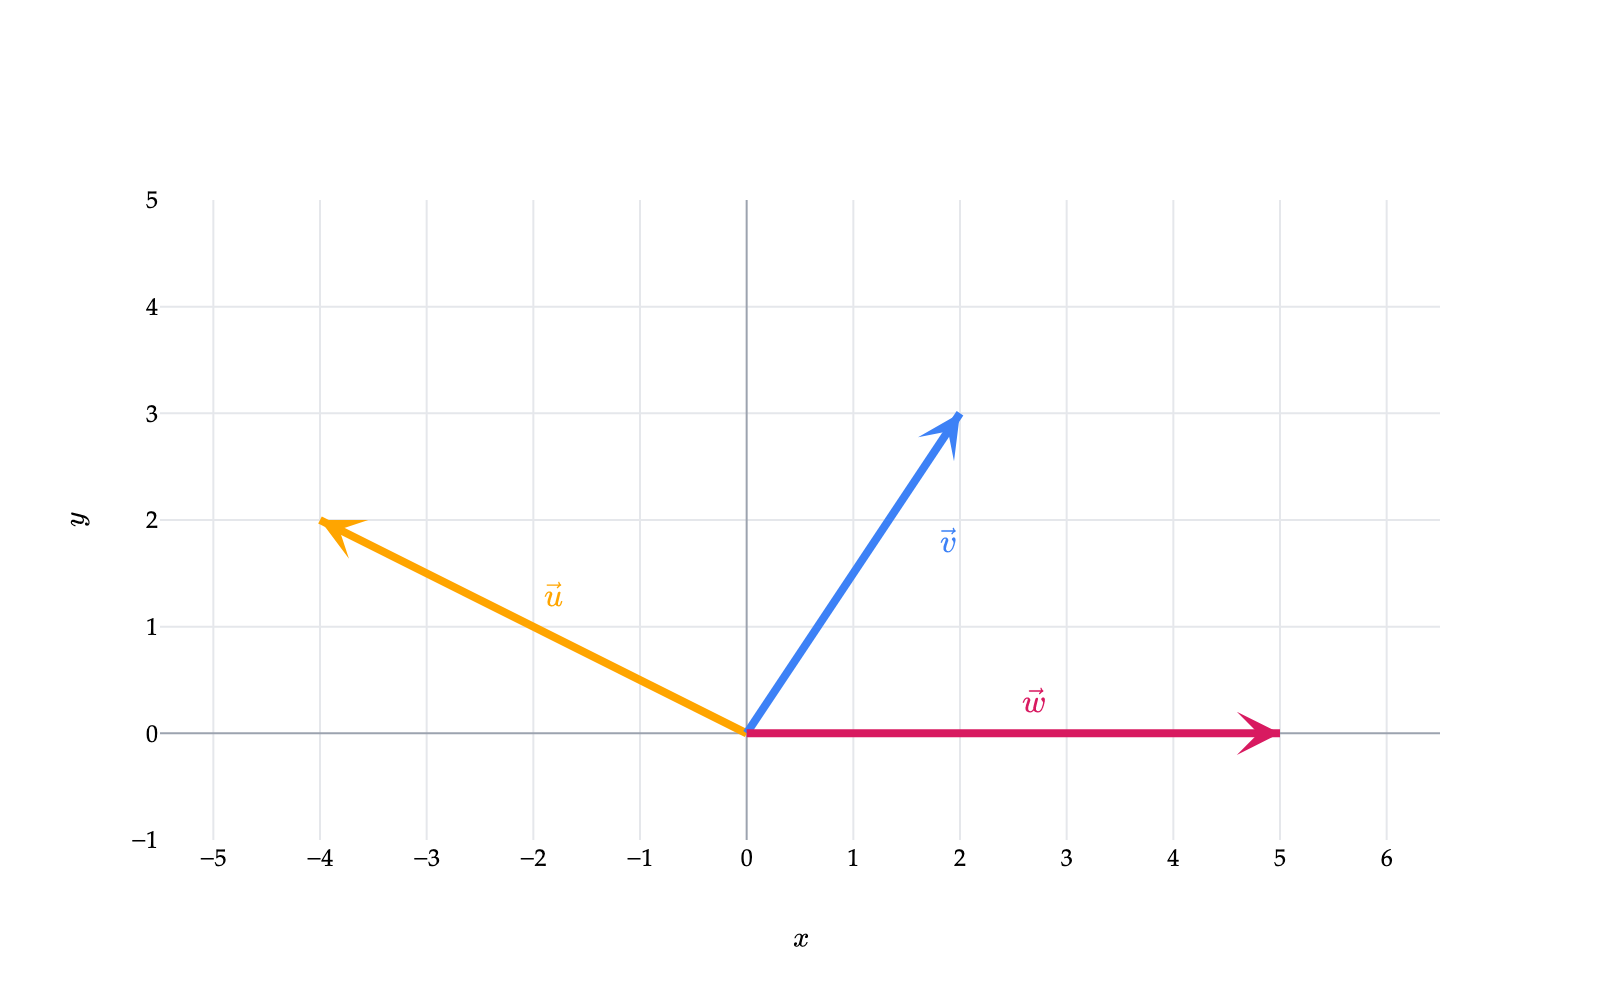

In [2]:
vectors = [
    ((-4, 2), "orange", r"$\vec u$"),
    ((2, 3), "#3d81f6", r"$\vec v$"),
    ((5, 0), "#d81a60", r"$\vec w$"),
]
fig = plot_vectors(vectors, vdeltax=0.2, vdeltay=0.35)
fig.update_layout(
    width=800, height=500,
    xaxis_title="$x$", yaxis_title="$y$", showlegend=False,
)
fig.update_xaxes(range=[-5, 6], dtick=1, scaleanchor="y")
fig.update_yaxes(range=[-1, 5], dtick=1)
_style_plotly(fig, renderer="png")

_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6", 2: "#d81a60"})

fig.layout.annotations[3].x += 0.7  # Move the v label to the right of its arrow.

fig.show(scale=2)

We often think of a vector as an object with a **magnitude** and **direction**:
- The magnitude of a vector is the **length** of the corresponding arrow; we will define this formally in Chapter 1.5. 
- The direction of a vector has a formal definition that we will cover in due time. To get you thinking about what the definition of a vector's direction might be, consider the fact that $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$, $\begin{bmatrix} 2 \\ 4 \end{bmatrix}$, and $\begin{bmatrix} 100 \\ 200 \end{bmatrix}$ all point in the same direction, so the formal definitions of their directions must all be the same.

But, a vector doesn't inherently have a fixed position! The arrow from $(0, 0)$ to $(2, 3)$ is the same as the arrow from $(3, 1)$ to $(5, 4)$. In both cases, to travel from the first point to the second, one moves $2$ units to the right and $3$ units up.

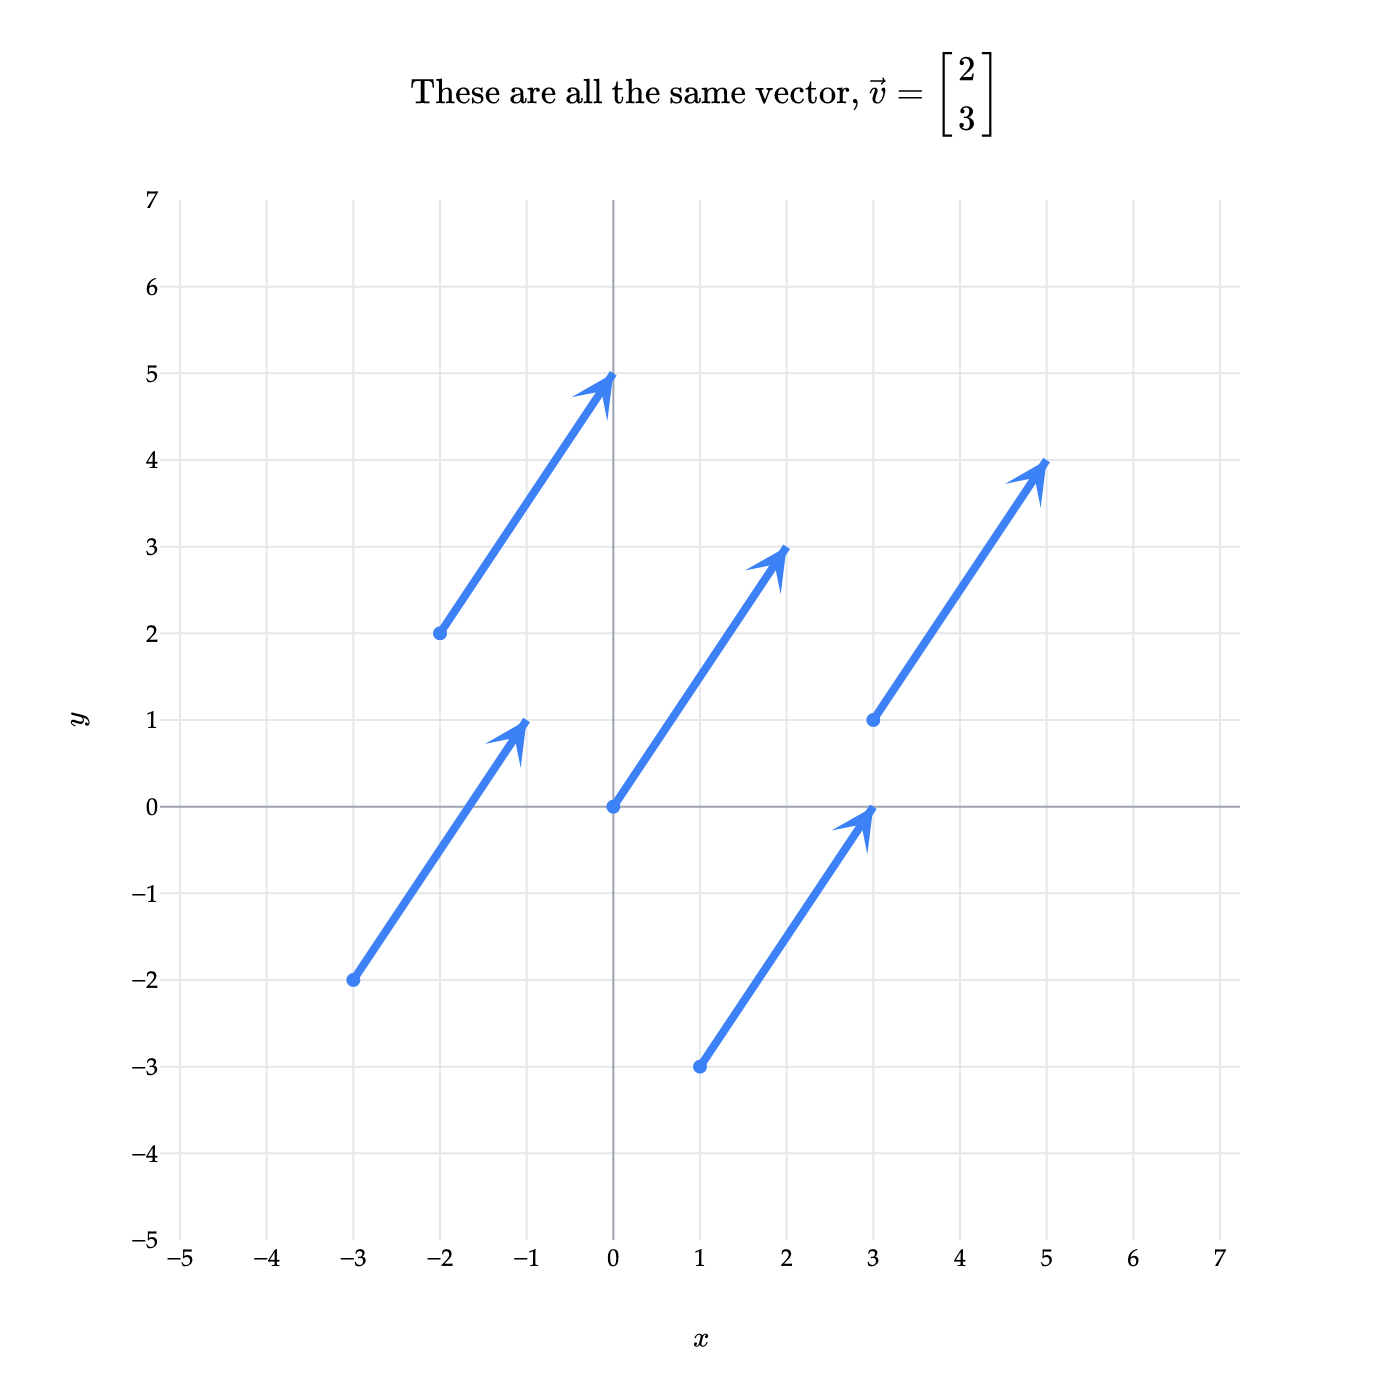

In [3]:
import numpy as np
import plotly.graph_objects as go

# The vector v = (2,3)
v = np.array([2, 3])

# Different initial points
starts = np.array([
    [0, 0],
    [3, 1],
    [-2, 2],
    [1, -3],
    [-3, -2],
])

fig = go.Figure()
for start in starts:
    end = start + v
    fig.add_trace(go.Scatter(
        x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
        line=dict(color="#3d81f6", width=4), showlegend=False,
        hovertemplate="(%{x}, %{y})<extra></extra>",
    ))
    fig.add_annotation(
        x=end[0], y=end[1], ax=start[0], ay=start[1],
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
        arrowcolor="#3d81f6",
    )
    fig.add_trace(go.Scatter(
        x=[start[0]], y=[start[1]], mode="markers",
        marker=dict(size=7, color="#3d81f6"), showlegend=False,
        hovertemplate="start: (%{x}, %{y})<extra></extra>",
    ))

fig.update_layout(
    title=r"$$\text{These are all the same vector, } \vec v = \begin{bmatrix} 2 \\ 3 \end{bmatrix}$$", width=700, height=700,
    xaxis_title="$x$", yaxis_title="$y$",
)
fig.update_xaxes(range=[-5, 7], dtick=1, scaleanchor="y")
fig.update_yaxes(range=[-5, 7], dtick=1)
_style_plotly(fig, renderer="png")
fig.show(scale=2)


So, we can think of a vector as representing the displacement between points.

Vectors have both a magnitude and direction. Real numbers, on the other hand, only have a numerical value, with no direction. To emphasize this difference, we will often call real numbers **scalars**. A scalar is just a single number.

### Collections of vectors

You might have noticed that all of the example visualizations above involved vectors with exactly two components.

Indeed: 
- Vectors with two components can be visualized in two-dimensional space.
- Vectors with three components can be visualized in three-dimensional space. 

We can't directly visualize vectors with more than three components in three-dimensional space. But that doesn't mean they don't exist! Vectors are often used to store real-world data, for use in building models for making predictions. Using an example from Chapter 1.3, if we collected a student's age, height in inches, shoe size, number of siblings, and number of followers on Instagram, we could represent that student's data as a vector with five components.

$$\vec x = \begin{bmatrix} 19 \\ 68 \\ 10 \\ 2 \\ 450 \end{bmatrix}$$

In this setting, the components of $\vec x$ represent the student's age, height, shoe size, number of siblings, and number of Instagram followers, in that order. We aren't thinking of the student data vector as measuring any sort of displacement; it is being used to represent data.

It is useful to have a name to refer to the set of all vectors with a fixed number of components. In general, **the set of vectors with $n$ components is called $\mathbb{R}^n$**. We also referred to this set as the $n$-dimensional Euclidean space in Chapter 1.3. Think of $n$ as the general placeholder for the number of components in a vector.

For instance, if $\vec w = \begin{bmatrix} 3 \\ 5 \\ 2 \end{bmatrix}$ and $\vec x = \begin{bmatrix} 2.1 \\ e \\ 1.2 \\ 3.5 \end{bmatrix}$, then it is valid to write

$$\vec w \in \mathbb{R}^3$$

and

$$\vec x \in \mathbb{R}^4.$$

These statements are pronounced "**w is in R three**" and "x is in R four", respectively.

In [4]:
A = np.array([1, 2])
B = np.array([4, 1])
D = np.array([-1, 5])
C = np.array([2, 4])

vectors = [
    ((A, B), "orange", r"$\vec u$"),
    ((D, C), "orange", r"$\vec u$"),
    ((A, D), "#3d81f6", r"$\vec v$"),
    ((B, C), "#3d81f6", r"$\vec v$"),
]
fig = plot_vectors_non_origin(vectors, vdeltax=0.2, vdeltay=0.25)
points = [("A", A), ("B", B), ("C", C), ("D", D)]
fig.add_trace(go.Scatter(
    x=[point[0] for _, point in points],
    y=[point[1] for _, point in points],
    mode="markers+text",
    text=[f"{name} = ({point[0]}, {point[1]})" for name, point in points],
    textposition=["top right", "bottom right", "top right", "top right"],
    marker=dict(color="black", size=9),
    textfont=dict(color="black", size=15),
    hovertemplate="(%{x}, %{y})<extra></extra>",
    showlegend=False,
))
fig.update_layout(
    width=650, height=600,
    xaxis_title="$x$", yaxis_title="$y$", showlegend=False,
    margin=dict(l=50, r=40, t=30, b=50),
)
fig.update_xaxes(range=[-2, 5], dtick=1, scaleanchor="y")
fig.update_yaxes(range=[0, 6], dtick=1)
_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "orange", 1: "orange", 2: "#3d81f6", 3: "#3d81f6"})
fig.data[-1].marker.color = "black"
fig.data[-1].textfont.color = "black"
fig.write_image(_notes_root / "ch01" / "imgs" / "activity1-parallelogram.png", scale=2)

:::{tip} Activity 1

The points $A=(1,2)$, $B=(4,1)$, $C=(2, 4)$, and $D=(-1, 5)$ are the vertices of a parallelogram.
1. Draw the parallelogram.
1. Let $\vec u$ represent the displacement from $A$ to $B$, and $\vec v$ represent the displacement from $A$ to $D$. Find $\vec u$ and $\vec v$.
1. $\vec u$ also represents the displacement between two other points on the parallelogram. Which two points?

:::{tip} Solution
:class: dropdown

![The four points and the two pairs of equal displacement vectors forming the parallelogram.](imgs/activity1-parallelogram.png)

The two vectors starting at $A$ are

$$\vec u = \begin{bmatrix} 4-1 \\ 1-2 \end{bmatrix} = \begin{bmatrix} 3 \\ -1 \end{bmatrix}$$
and
$$\vec v = \begin{bmatrix} -1-1 \\ 5-2 \end{bmatrix} = \begin{bmatrix} -2 \\ 3 \end{bmatrix}.$$

$\vec u$ also represents the displacement from $D$ to $C$, and $\vec v$ also represents the displacement from $B$ to $C$.
:::

---

## Addition

Vectors are new mathematical objects, and as such, we need to carefully define the operations that they support. Our focus for now is primarily vectors in $\mathbb{R}^2$ and $\mathbb{R}^3$ – that is, vectors with two or three components – since we can more easily visualize these vectors, and we want to build your geometric intuition. That said, we will still provide general formulas for vectors with any number of components, since it's important to have a concrete sense of how these operations work.

Let's start with vector addition. First, to be able to add two vectors, it is necessary that they **have the same number of components**. Given that is the case, the sum of two vectors is a new vector whose components are the sums of the components of the original two.

For example, if $\color{orange}\vec u = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ and $\color{#3d81f6}\vec v = \begin{bmatrix} 3 \\ -1 \end{bmatrix}$, then $${\color{orange}\vec u} + {\color{#3d81f6}\vec v} = \begin{bmatrix} {\color{orange} 1} + {\color{#3d81f6} 3} \\ {\color{orange}2} + {\color{#3d81f6} (-1)} \end{bmatrix} = {\color{#d81a60}\begin{bmatrix} 4 \\ 1 \end{bmatrix}}.$$

$\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ are both vectors in $\mathbb{R}^2$, and so is their sum. If $\color{#3d81f6} \vec v$ had, say, three components, we couldn't add it to $\color{orange} \vec u$.

Let's visualize the sum of these two vectors geometrically.

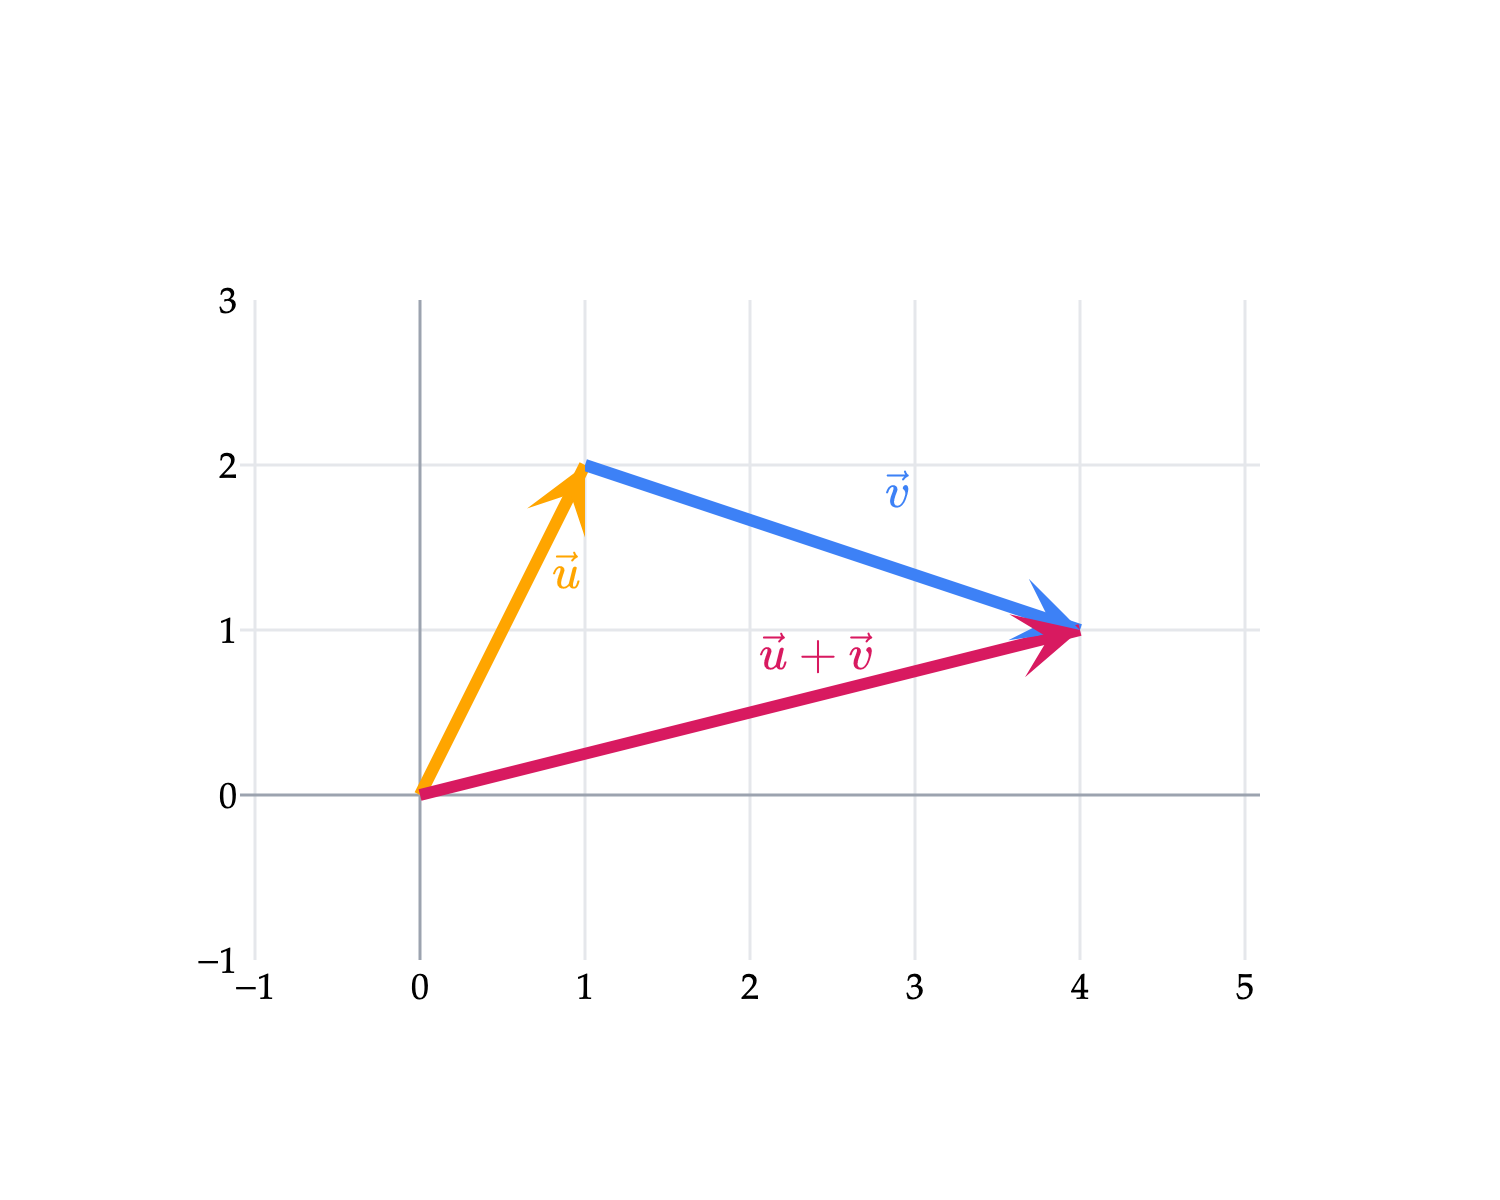

In [5]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---

# Define vectors in the format: (((start_x, start_y), (end_x, end_y)), color, label)
vectors = [
    (((0, 0), (1, 2)), 'orange', r'$\vec u$'),              # u starts at origin
    (((1, 2), (4, 1)), '#3d81f6', r'$\vec v$'),                # v starts at tip of u
    (((0, 0), (4, 1)), 'green', r'$\vec u + \vec v$')       # u+v starts at origin, ends at tip of v
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)

fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-2, 7))
fig.update_yaxes(range=[-1, 3], tickvals=np.arange(-2, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6"})
fig.show(scale=3)

To compute $\color{#d81a60} \vec u + \vec v$, we started by drawing $\color{orange} \vec u$ at the origin, and placed $\color{#3d81f6} \vec v$'s **tail** at the **tip** of $\color{orange} \vec u$. Remember that vectors have no fixed position, so this is legal – $\color{#3d81f6} \vec v$ can be placed at $(1, 2)$ just as well as it can be placed at $(0, 0)$.

After placing $\color{#3d81f6} \vec v$'s tail at the tip of $\color{orange} \vec u$, the vector from the origin to the tip of $\color{#3d81f6} \vec v$ is the sum, $\color{#d81a60} \vec u + \vec v$. This is sometimes called the **tip-to-tail** method.

Does it matter that we "started" with $\color{orange} \vec u$ at the origin? No! We could have placed $\color{#3d81f6} \vec v$ at the origin and $\color{orange} \vec u$ at its tip, and we would have ended up with the same sum.

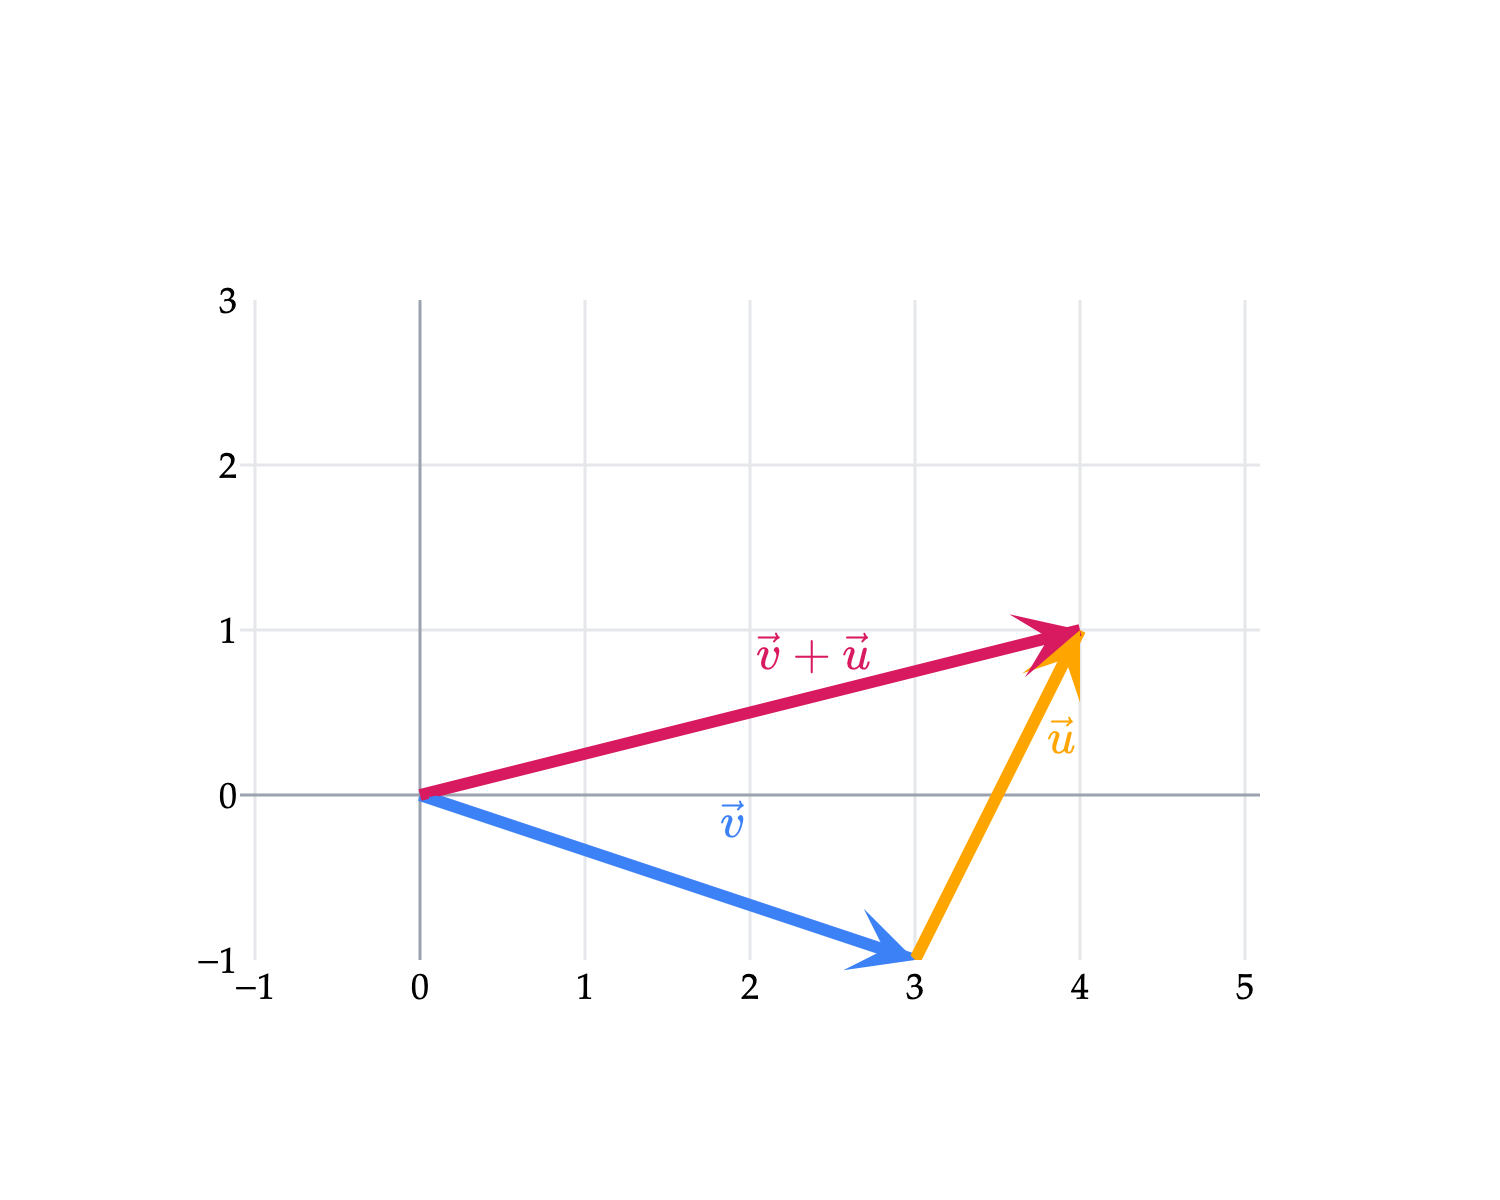

In [6]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---

# Define vectors in the format: (((start_x, start_y), (end_x, end_y)), color, label)
vectors = [
    (((0, 0), (3, -1)), '#3d81f6', r'$\vec v$'),              # v starts at origin
    (((3, -1), (4, 1)), 'orange', r'$\vec u$'),                # u starts at tip of v
    (((0, 0), (4, 1)), 'green', r'$\vec v + \vec u$')       # v+u starts at origin, ends at tip of u
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)

fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-2, 7))
fig.update_yaxes(range=[-1, 3], tickvals=np.arange(-2, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "#3d81f6", 1: "orange"})
fig.show(scale=3)

What this is showing us is that vector addition is **commutative**: the order in which we add vectors does not matter.

Another viewpoint – one that will be especially important when we _subtract_ two vectors – is to place both vectors $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ at the origin, and interpret $\color{#d81a60} \vec u + \vec v$ as the diagonal of the parallelogram formed by the two vectors. (For more on parallelograms, see Activity 1 from above.)

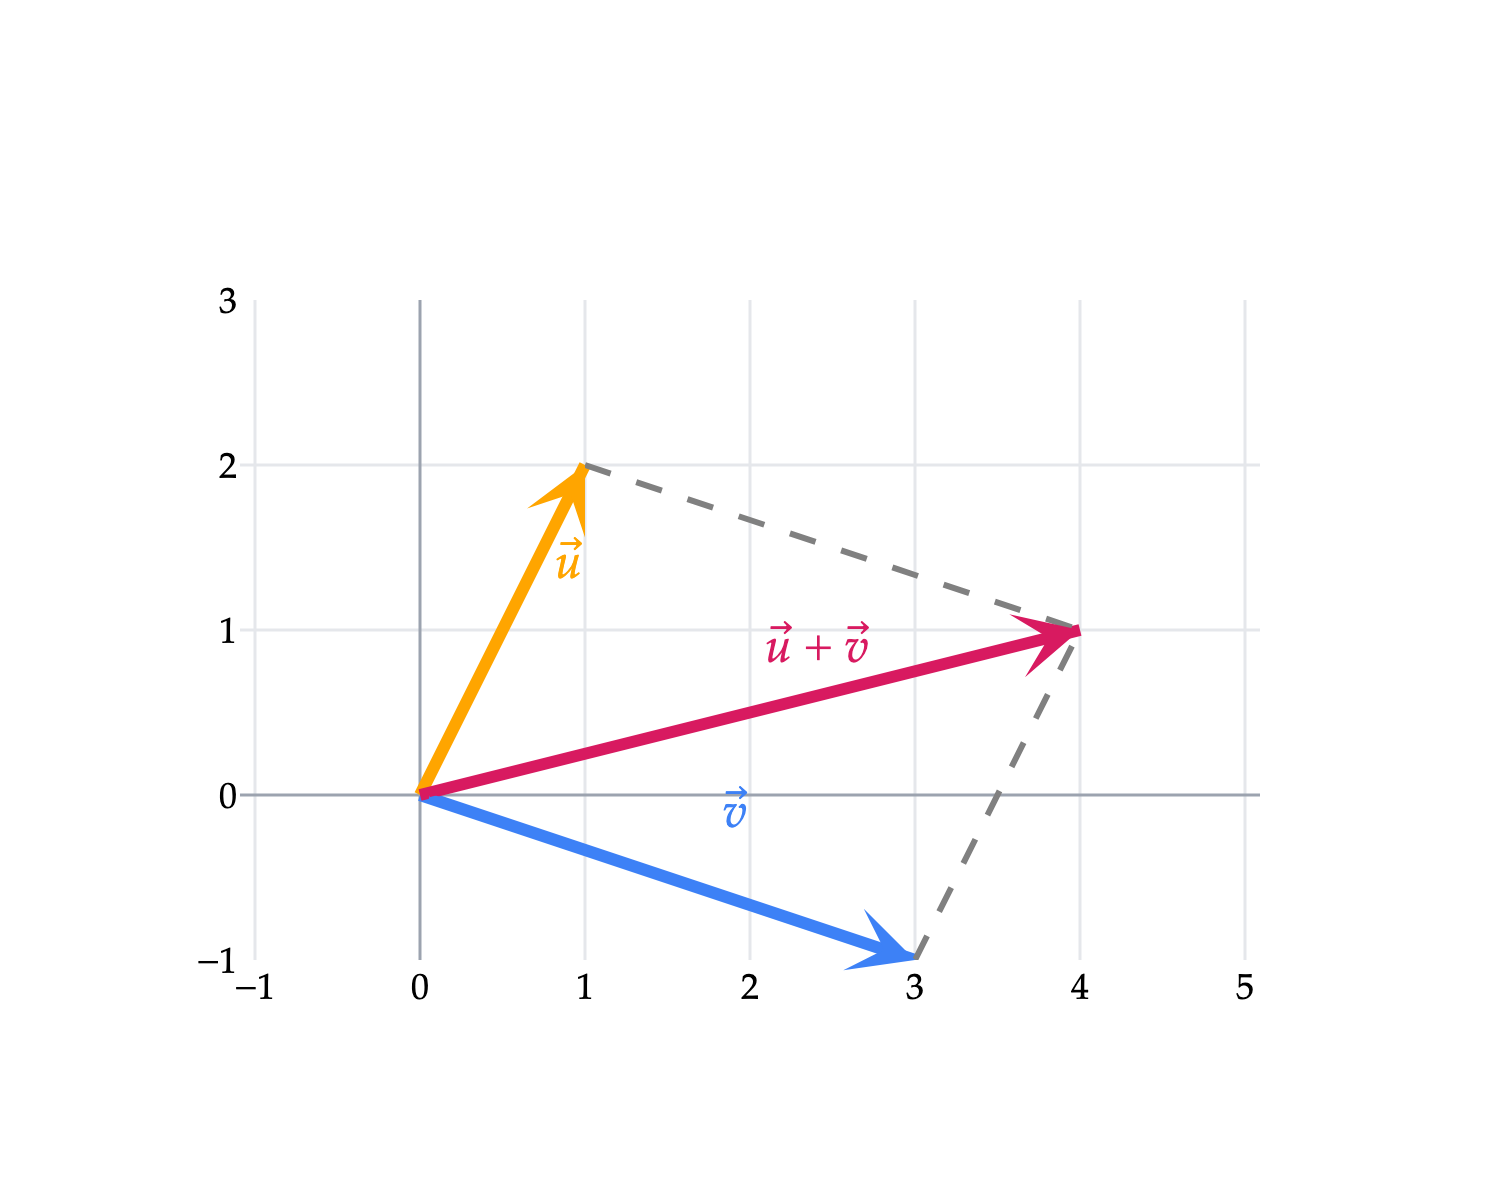

In [7]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---

# Define the primary vectors and their resultant sum starting from the origin
vectors = [
    (((0, 0), (1, 2)), 'orange', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), '#3d81f6', '<i>v</i>\u20D7'),
    (((0, 0), (4, 1)), 'green', '<i>u</i>\u20D7 + <i>v</i>\u20D7')
]

# Generate the figure using the custom utility
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)

# Add dashed lines to explicitly show the parallelogram
# 1. Edge parallel to v, starting at the tip of u (1, 2) and ending at the sum (4, 1)
fig.add_trace(go.Scatter(
    x=[1, 4], y=[2, 1], mode='lines', 
    line=dict(color='gray', width=2, dash='dash'), 
    showlegend=False, hoverinfo='skip'
))

# 2. Edge parallel to u, starting at the tip of v (3, -1) and ending at the sum (4, 1)
fig.add_trace(go.Scatter(
    x=[3, 4], y=[-1, 1], mode='lines', 
    line=dict(color='gray', width=2, dash='dash'), 
    showlegend=False, hoverinfo='skip'
))

# Format the layout to keep the grid perfectly square
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")

# Set the grid to comfortably frame the entire parallelogram
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-2, 7))
fig.update_yaxes(range=[-1, 3], tickvals=np.arange(-2, 5))

# Export statically
_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6"})
fig.show(scale=3)

Vector addition works the same way in $\mathbb{R}^3$. For example, let

$$ {\color{orange}\vec u = \begin{bmatrix} 2 \\ 2 \\ 1 \end{bmatrix}}, \qquad {\color{#3d81f6}\vec v = \begin{bmatrix} -1 \\ 2 \\ 2 \end{bmatrix}}.$$

Drawing ${\color{#3d81f6}\vec v}$ from the tip of ${\color{orange}\vec u}$ gives the sum ${\color{#d81a60}\vec u + \vec v = \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}}$.

In [8]:
# Draw u, then v from the tip of u, and connect the origin to their sum.
vectors = [
    (((0, 0, 0), (2, 2, 1)), "orange", "<i>u</i>\u20D7"),
    (((2, 2, 1), (1, 4, 3)), "#3d81f6", "<i>v</i>\u20D7"),
    (((0, 0, 0), (1, 4, 3)), "#d81a60", "<i>u</i>\u20D7 + <i>v</i>\u20D7"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.2, vdeltay=0.2, vdeltaz=0.2)
fig.update_layout(
    width=600, height=500,
    scene=dict(
        xaxis=dict(range=[-1, 3], dtick=1),
        yaxis=dict(range=[0, 5], dtick=1),
        zaxis=dict(range=[0, 4], dtick=1),
        aspectratio=dict(x=1, y=1, z=1),
    ),
)

_style_plotly(fig, renderer="plotly_mimetype")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6", 2: "#d81a60"})
fig.show()

How do we add three or more vectors? **Associativity** says that the placement of parentheses does not matter:

$$ ({\color{orange}\vec u} + {\color{#3d81f6}\vec v}) + {\color{#004d40}\vec w} = {\color{orange}\vec u} + ({\color{#3d81f6}\vec v} + {\color{#004d40}\vec w}). $$

Let's illustrate using the following three vectors in $\mathbb{R}^2$:

$$ {\color{orange}\vec u = \begin{bmatrix} 1 \\ 2 \end{bmatrix}}, \qquad {\color{#3d81f6}\vec v = \begin{bmatrix} 3 \\ -1 \end{bmatrix}}, \qquad {\color{#004d40}\vec w = \begin{bmatrix} -1 \\ 2 \end{bmatrix}}. $$

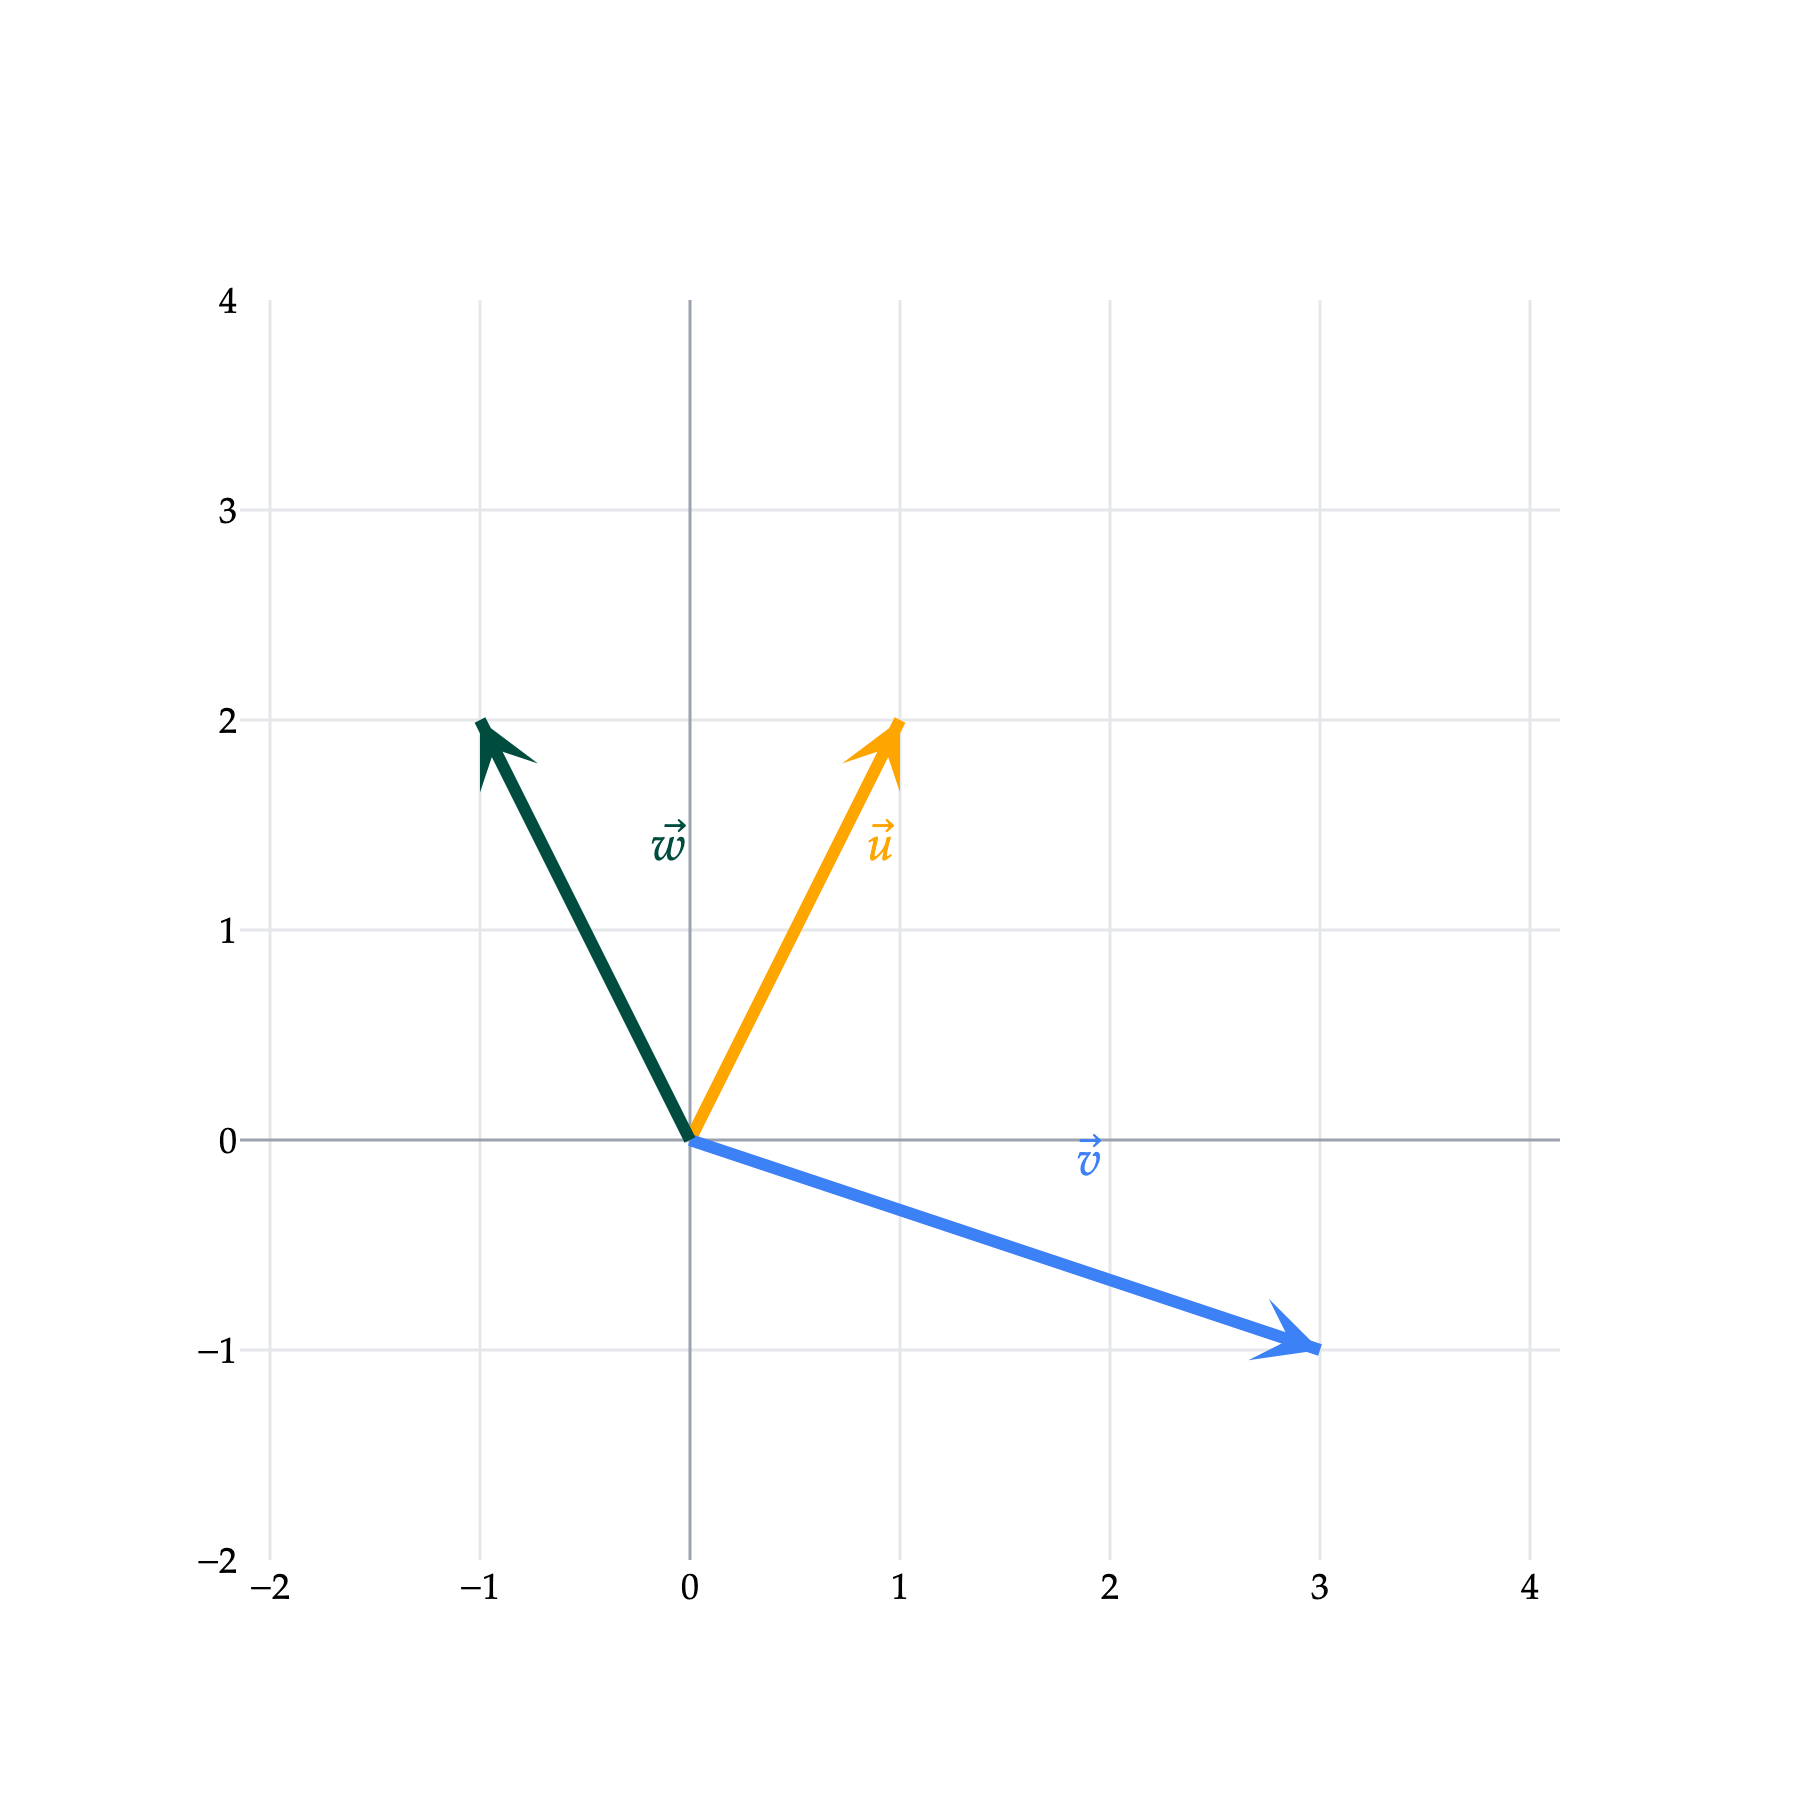

In [9]:
vectors = [
    (((0, 0), (1, 2)), "orange", "<i>u</i>\u20D7"),
    (((0, 0), (3, -1)), "#3d81f6", "<i>v</i>\u20D7"),
    (((0, 0), (-1, 2)), "#004d40", "<i>w</i>\u20D7"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4)
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-2, 4], tickvals=np.arange(-2, 5))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6", 2: "#004d40"})
fig.show(scale=3)

To evaluate $({\color{orange}\vec u} + {\color{#3d81f6}\vec v}) + {\color{#004d40}\vec w}$:
1. First, we compute $$ {\color{#d81a60}\vec u + \vec v = \begin{bmatrix}4 \\ 1\end{bmatrix}}.$$
2. Then, we add the result to ${\color{#004d40}\vec w}$:

$$ {\color{#d81a60}(\vec u + \vec v)} + {\color{#004d40}\vec w} = {\color{#d81a60}\begin{bmatrix}4 \\ 1\end{bmatrix}} + {\color{#004d40}\begin{bmatrix}-1 \\ 2\end{bmatrix}} = \begin{bmatrix}3 \\ 3\end{bmatrix}. $$

The faded vectors are ${\color{orange}\vec u}$ and ${\color{#3d81f6}\vec v}$, the emphasized vectors are their sum ${\color{#d81a60}\vec u + \vec v}$ and ${\color{#004d40}\vec w}$, and the black vector is the final sum, $\begin{bmatrix} 3 \\ 3 \end{bmatrix}$.

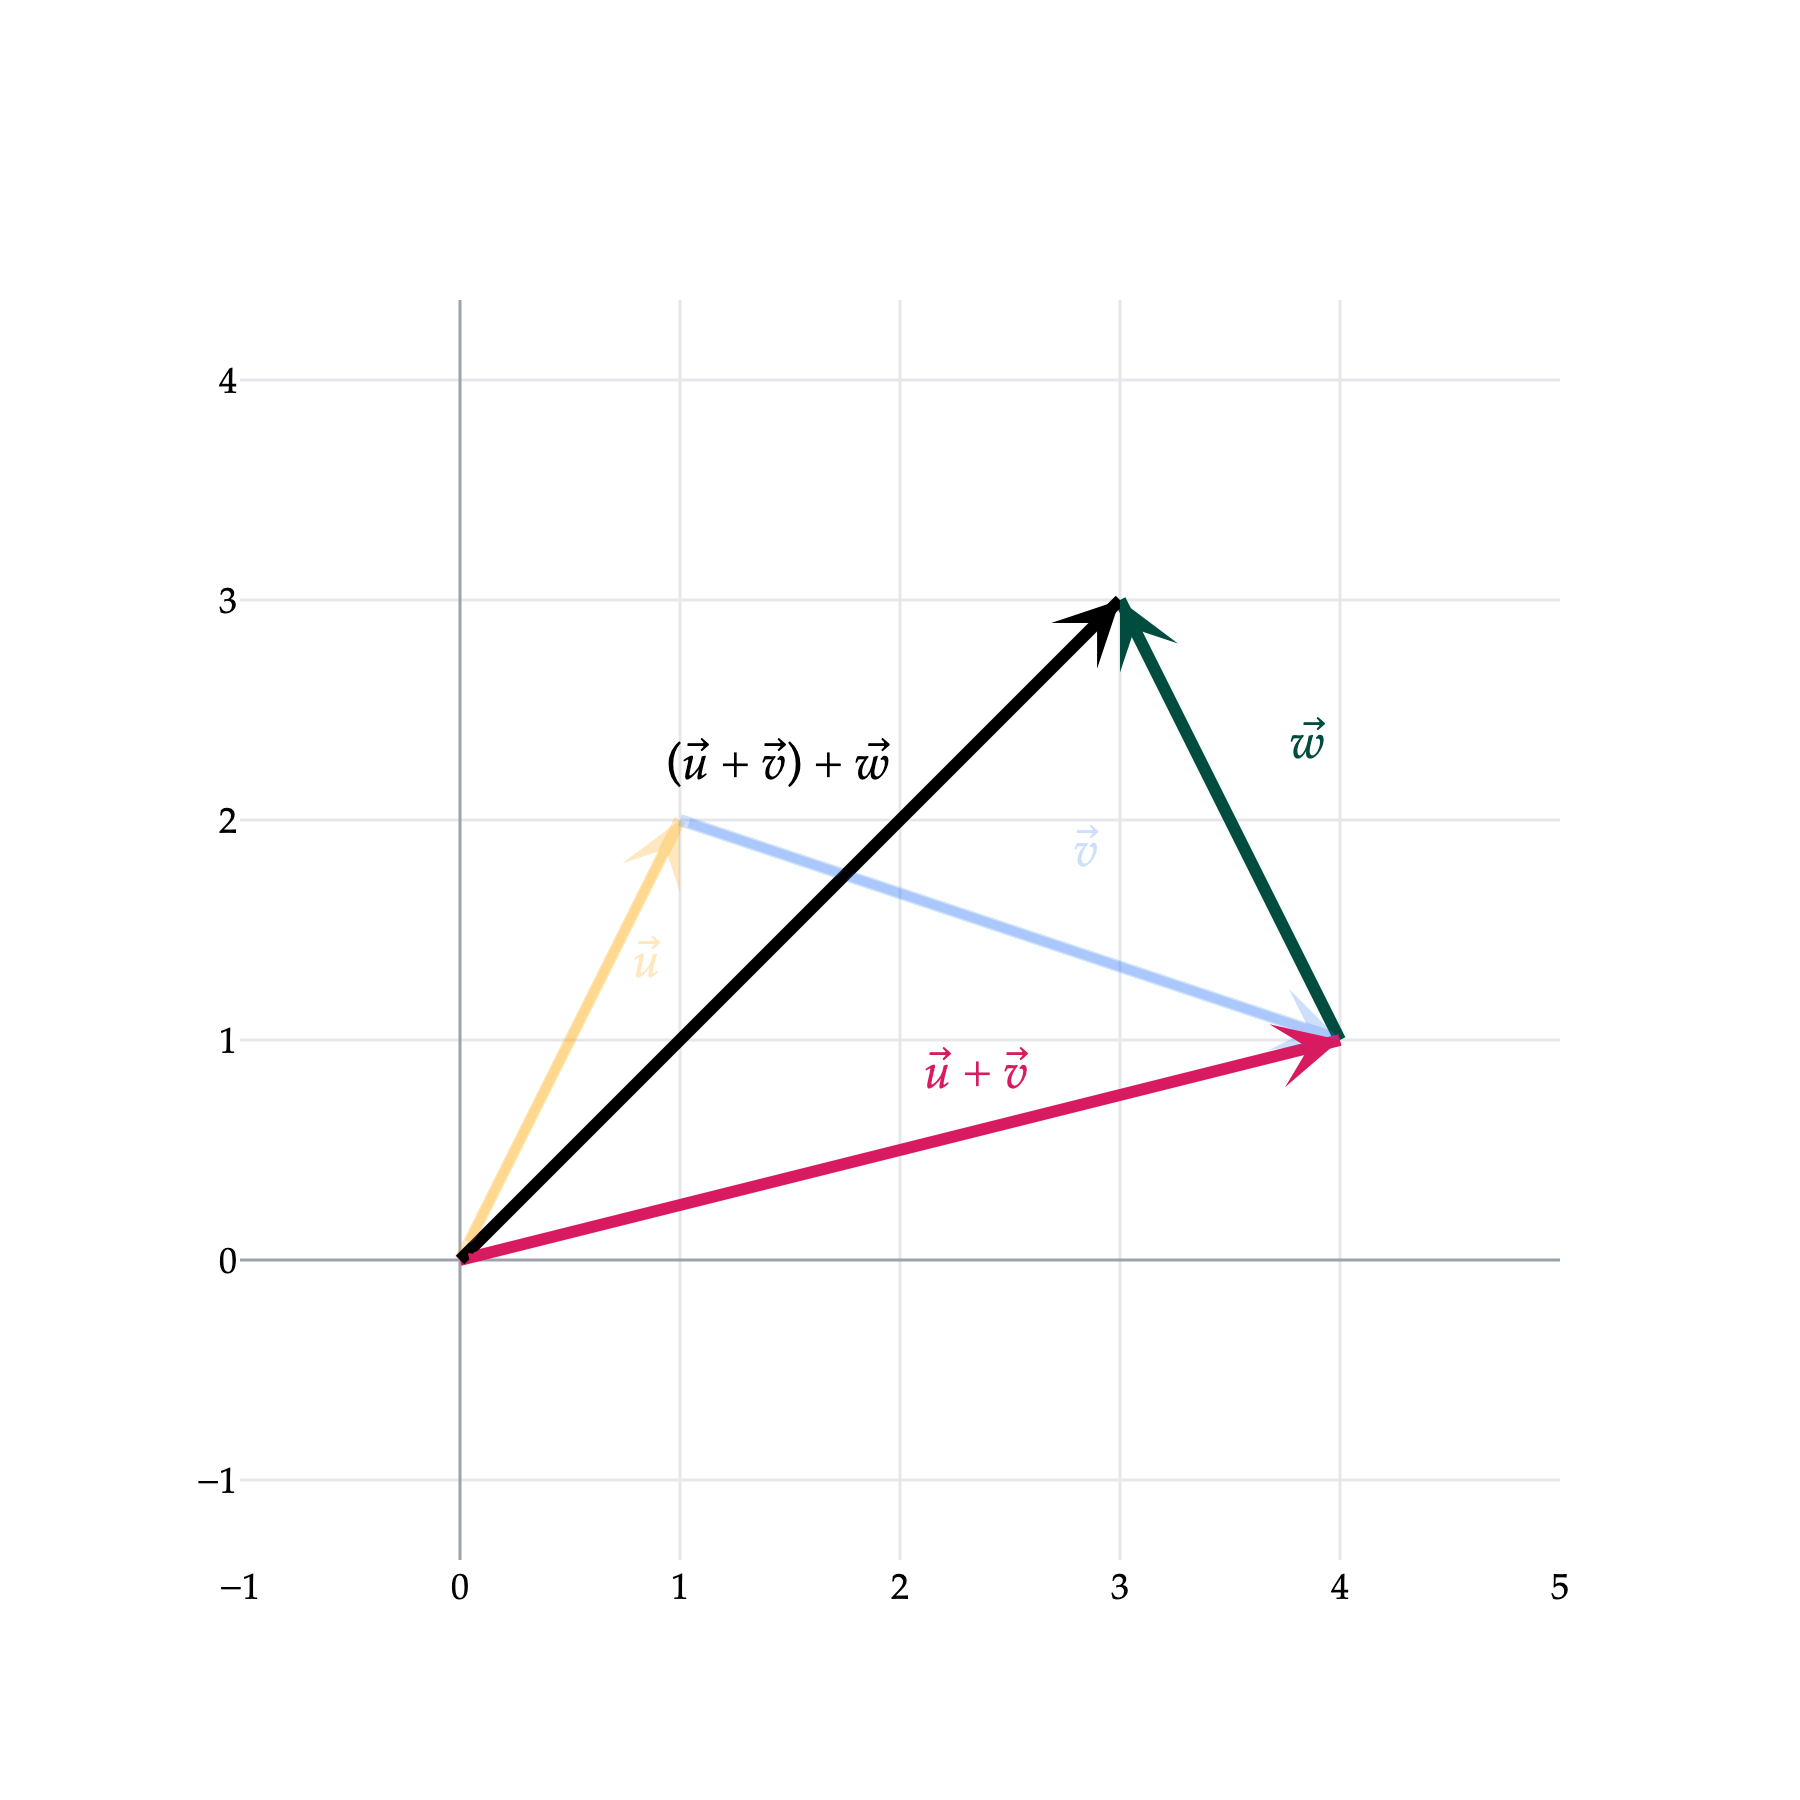

In [10]:
# Follow the path u, then v, then w.
vectors = [
    (((0, 0), (1, 2)), "orange", "<i>u</i>\u20D7"),
    (((1, 2), (4, 1)), "#3d81f6", "<i>v</i>\u20D7"),
    (((4, 1), (3, 3)), "#004d40", "<i>w</i>\u20D7"),
    (((0, 0), (4, 1)), "#d81a60", "<i>u</i>\u20D7 + <i>v</i>\u20D7"),
    (((0, 0), (3, 3)), "black", "(<i>u</i>\u20D7 + <i>v</i>\u20D7) + <i>w</i>\u20D7"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.35, vdeltay=0.35)
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-1, 4], tickvals=np.arange(-1, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig, vectors,
    {0: "orange", 1: "#3d81f6", 2: "#004d40", 3: "#d81a60", 4: "black"},
)
for index in (0, 1):
    fig.data[index].opacity = 0.25
    for annotation in fig.layout.annotations[2 * index:2 * index + 2]:
        annotation.opacity = 0.25
fig.layout.annotations[9].x -= 0.4
fig.layout.annotations[9].y += 0.4
fig.show(scale=3)

To evaluate ${\color{orange}\vec u} + ({\color{#3d81f6}\vec v} + {\color{#004d40}\vec w})$:
1. First, we compute $$ {\color{purple}\vec v + \vec w = \begin{bmatrix}2 \\ 1\end{bmatrix}}.$$
1. Then, we add the result to ${\color{orange}\vec u}$:
$$ {\color{orange}\vec u} + {\color{purple}(\vec v + \vec w)} = \begin{bmatrix}1 \\ 2\end{bmatrix} + \begin{bmatrix}2 \\ 1\end{bmatrix} = \begin{bmatrix}3 \\ 3\end{bmatrix}. $$

In the diagram, the faded vectors show how we computed ${\color{purple}\vec v + \vec w}$. We then draw ${\color{orange}\vec u}$ at the origin and place a translated copy of ${\color{purple}\vec v + \vec w}$ at its tip.

Notice that the final sum is the same as above!

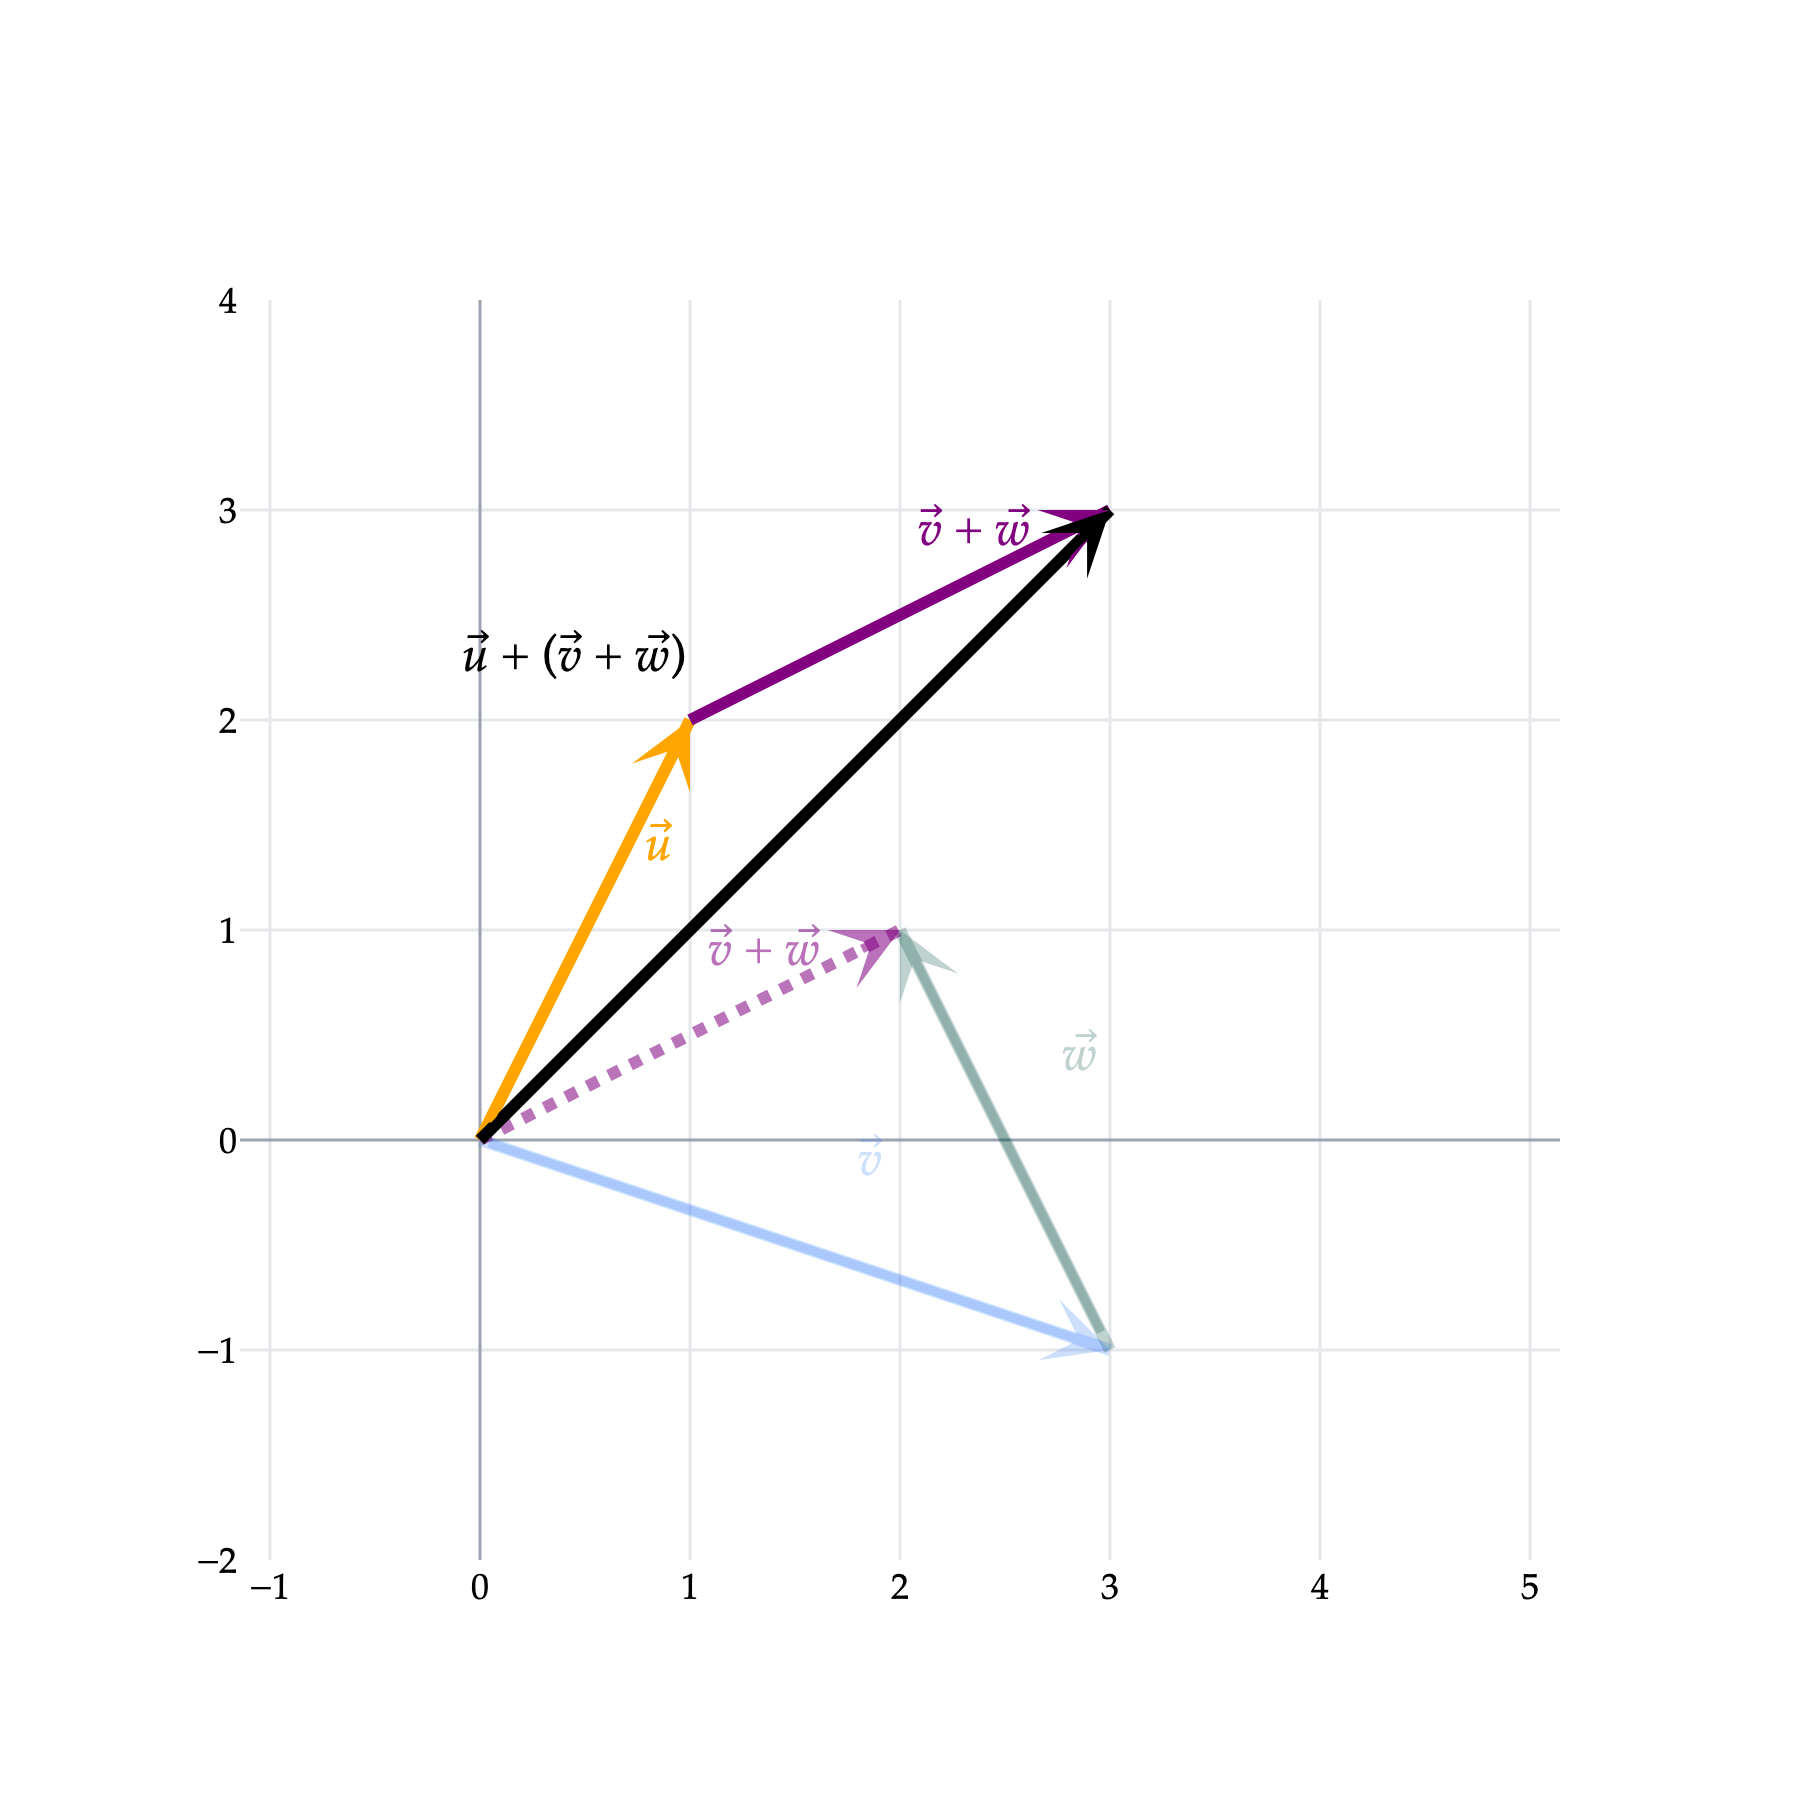

In [11]:
# Compute v + w, then add the translated sum to u.
vectors = [
    (((0, 0), (3, -1)), "#3d81f6", "<i>v</i>\u20D7"),
    (((3, -1), (2, 1)), "#004d40", "<i>w</i>\u20D7"),
    (((0, 0), (1, 2)), "orange", "<i>u</i>\u20D7"),
    (((1, 2), (3, 3)), "purple", "<i>v</i>\u20D7 + <i>w</i>\u20D7"),
    (((0, 0), (2, 1)), "purple", "<i>v</i>\u20D7 + <i>w</i>\u20D7"),
    (((0, 0), (3, 3)), "black", "<i>u</i>\u20D7 + (<i>v</i>\u20D7 + <i>w</i>\u20D7)"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.35, vdeltay=0.4)
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 5], tickvals=np.arange(-1, 6))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig, vectors,
    {0: "#3d81f6", 1: "#004d40", 2: "orange", 3: "purple", 4: "purple", 5: "black"},
)
for index in (0, 1):
    fig.data[index].opacity = 0.25
    for annotation in fig.layout.annotations[2 * index:2 * index + 2]:
        annotation.opacity = 0.25
fig.data[4].line.dash = "dot"
fig.data[4].opacity = 0.55
dotted_direction = np.array([2, 1]) / np.linalg.norm([2, 1])
fig.layout.annotations[8].ax = 2 - 0.25 * dotted_direction[0]
fig.layout.annotations[8].ay = 1 - 0.25 * dotted_direction[1]
fig.layout.annotations[8].opacity = 0.55
fig.layout.annotations[9].opacity = 0.55
fig.layout.annotations[11].x -= 1.4
fig.layout.annotations[11].y += 0.4
fig.show(scale=3)

Now that we have a solid understanding by way of examples, let us state a formal definition of vector addition. If $\vec v$ is a vector in $\mathbb{R}^n$, it's common to use the scalars $v_1, v_2, ..., v_n$ to represent the components of $\vec v$:

$$\vec v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}.$$

:::{note} Definition: Vector addition
Suppose ${\color{orange} \vec u}, {\color{#3d81f6} \vec v} \in \mathbb{R}^n$, i.e. both are vectors with $n$ components.

Then, the **sum** of ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ is defined as follows:

$${\color{orange} \vec u} + {\color{#3d81f6} \vec v} = {\color{orange} \begin{bmatrix} u_1 \\ u_2 \\ \vdots \\ u_n \end{bmatrix}} + {\color{#3d81f6} \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}} = \begin{bmatrix} {\color{orange} u_1} + {\color{#3d81f6} v_1} \\ {\color{orange} u_2} + {\color{#3d81f6} v_2} \\ \vdots \\ {\color{orange} u_n} + {\color{#3d81f6} v_n} \end{bmatrix}$$
:::

---

## Scalar multiplication

:::{note} Definition: Scalar multiplication
Suppose ${\color{#3d81f6} \vec v} \in \mathbb{R}^n$. The **scalar multiple** of $\color{#3d81f6}\vec v$ by a scalar $c \in \mathbb{R}$ is defined as follows:

$$c {\color{#3d81f6} \vec v} = c {\color{#3d81f6} \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}} = \begin{bmatrix} c {\color{#3d81f6} v_1} \\ c {\color{#3d81f6} v_2} \\ \vdots \\ c {\color{#3d81f6} v_n} \end{bmatrix}$$
:::

For example, if $${\color{#3d81f6}\vec v = \begin{bmatrix} 3 \\ -1 \end{bmatrix}}$$ then $$3 {\color{#3d81f6}\vec v} = \begin{bmatrix} 9 \\ -3 \end{bmatrix}.$$ Note that we have deliberately defined this operation as **scalar** multiplication, not just "multiplication" in general: this operation involves multiplying a vector by a scalar, not two vectors together. We will define _one_ way of multiplying vectors in Chapter 1.5, when we study the dot product.

Similar to vector addition, scalar multiplication can also be viewed geometrically. Consider $\vec v = \begin{bmatrix}3 \\ -1\end{bmatrix}$ along with two of its scalar multiples:

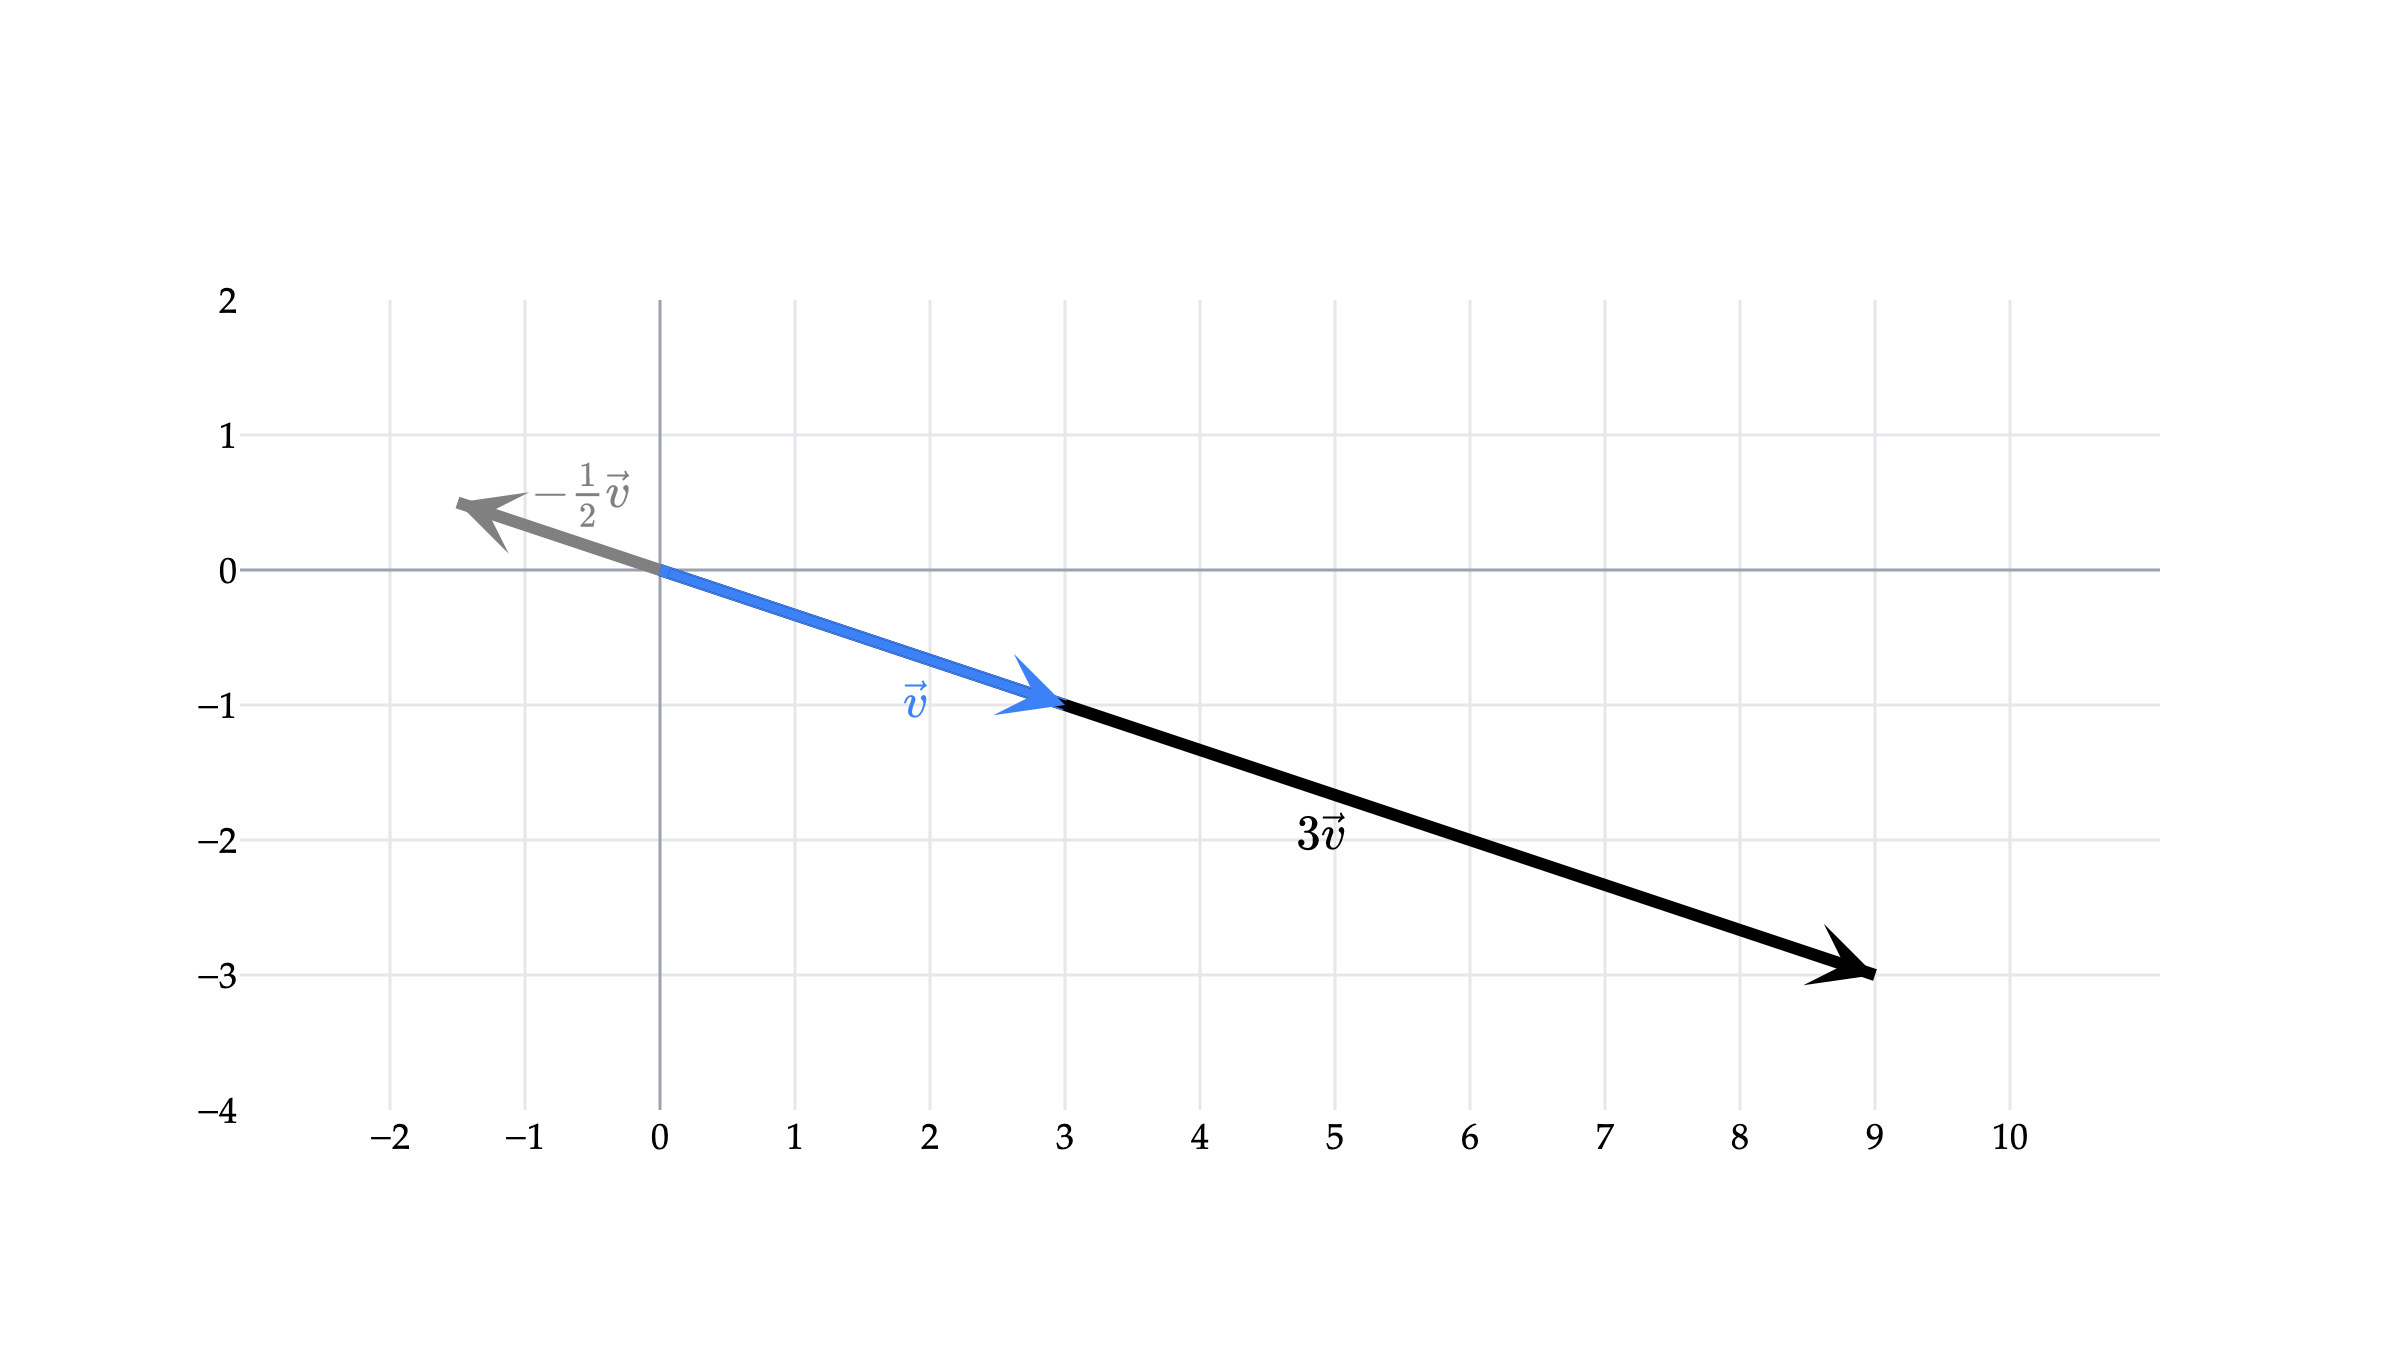

In [12]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---

# Draw 3v first so that v remains visible on top of it.
vectors = [
    ((9, -3), "black", r"$3\vec{v}$"),
    ((3, -1), "#3d81f6", r"$\vec{v}$"),
    ((-1.5, 0.5), "gray", r"$-\frac{1}{2}\vec{v}$"),
]

# Adjust vdeltax and vdeltay to position the labels
fig = plot_vectors(vectors, vdeltax=0.4, vdeltay=-0.4)

# Lock the aspect ratio so the scaling is visually accurate
fig.update_layout(width=800, height=450, yaxis_scaleanchor="x")

fig.update_xaxes(range=[-2, 10], tickvals=np.arange(-2, 11))
fig.update_yaxes(range=[-4, 2], tickvals=np.arange(-4, 3))

_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "black", 1: "#3d81f6", 2: "gray"})
fig.layout.annotations[5].x -= 0.25
fig.layout.annotations[5].y += 0.75
fig.show(scale=3)

The vector $3\vec v$ points in the same direction as $\vec v$ and is three times as long. The vector $-\frac{1}{2}\vec v$ points in the opposite direction and is half as long. In general, the absolute value of the scalar determines the change in length, while a negative sign reverses the direction.

It is worth questioning: what happens if we multiply a vector by the scalar $0$? The result is the **zero vector**, which we will discuss momentarily.

---

## Addition and scalar multiplication, together

Addition and scalar multiplication are the core building blocks of vectors. We can perform both operations in a single expression, e.g. $$3 \vec u - 4 \vec v.$$ A vector that results from scaling and adding one or more vectors is called a **linear combination** of the original vectors. As with vector addition, we will build an understanding through examples, before concluding with a formal definition.

### Subtraction

What does it mean to subtract one vector from another? To subtract $\color{#3d81f6} \vec v$ from $\color{orange} \vec u$, all we need to do is multiply $\color{#3d81f6} \vec v$ by the scalar $-1$, and add the resulting vector to $\color{orange} \vec u$.

$$ {\color{orange}\vec u} - ({\color{#3d81f6}\vec v}) = {\color{orange}\vec u} + (-\vec v).$$

Remember that $-\vec v$ is a vector with the same magnitude (length) as $\color{#3d81f6} \vec v$, just pointing in the opposite direction.

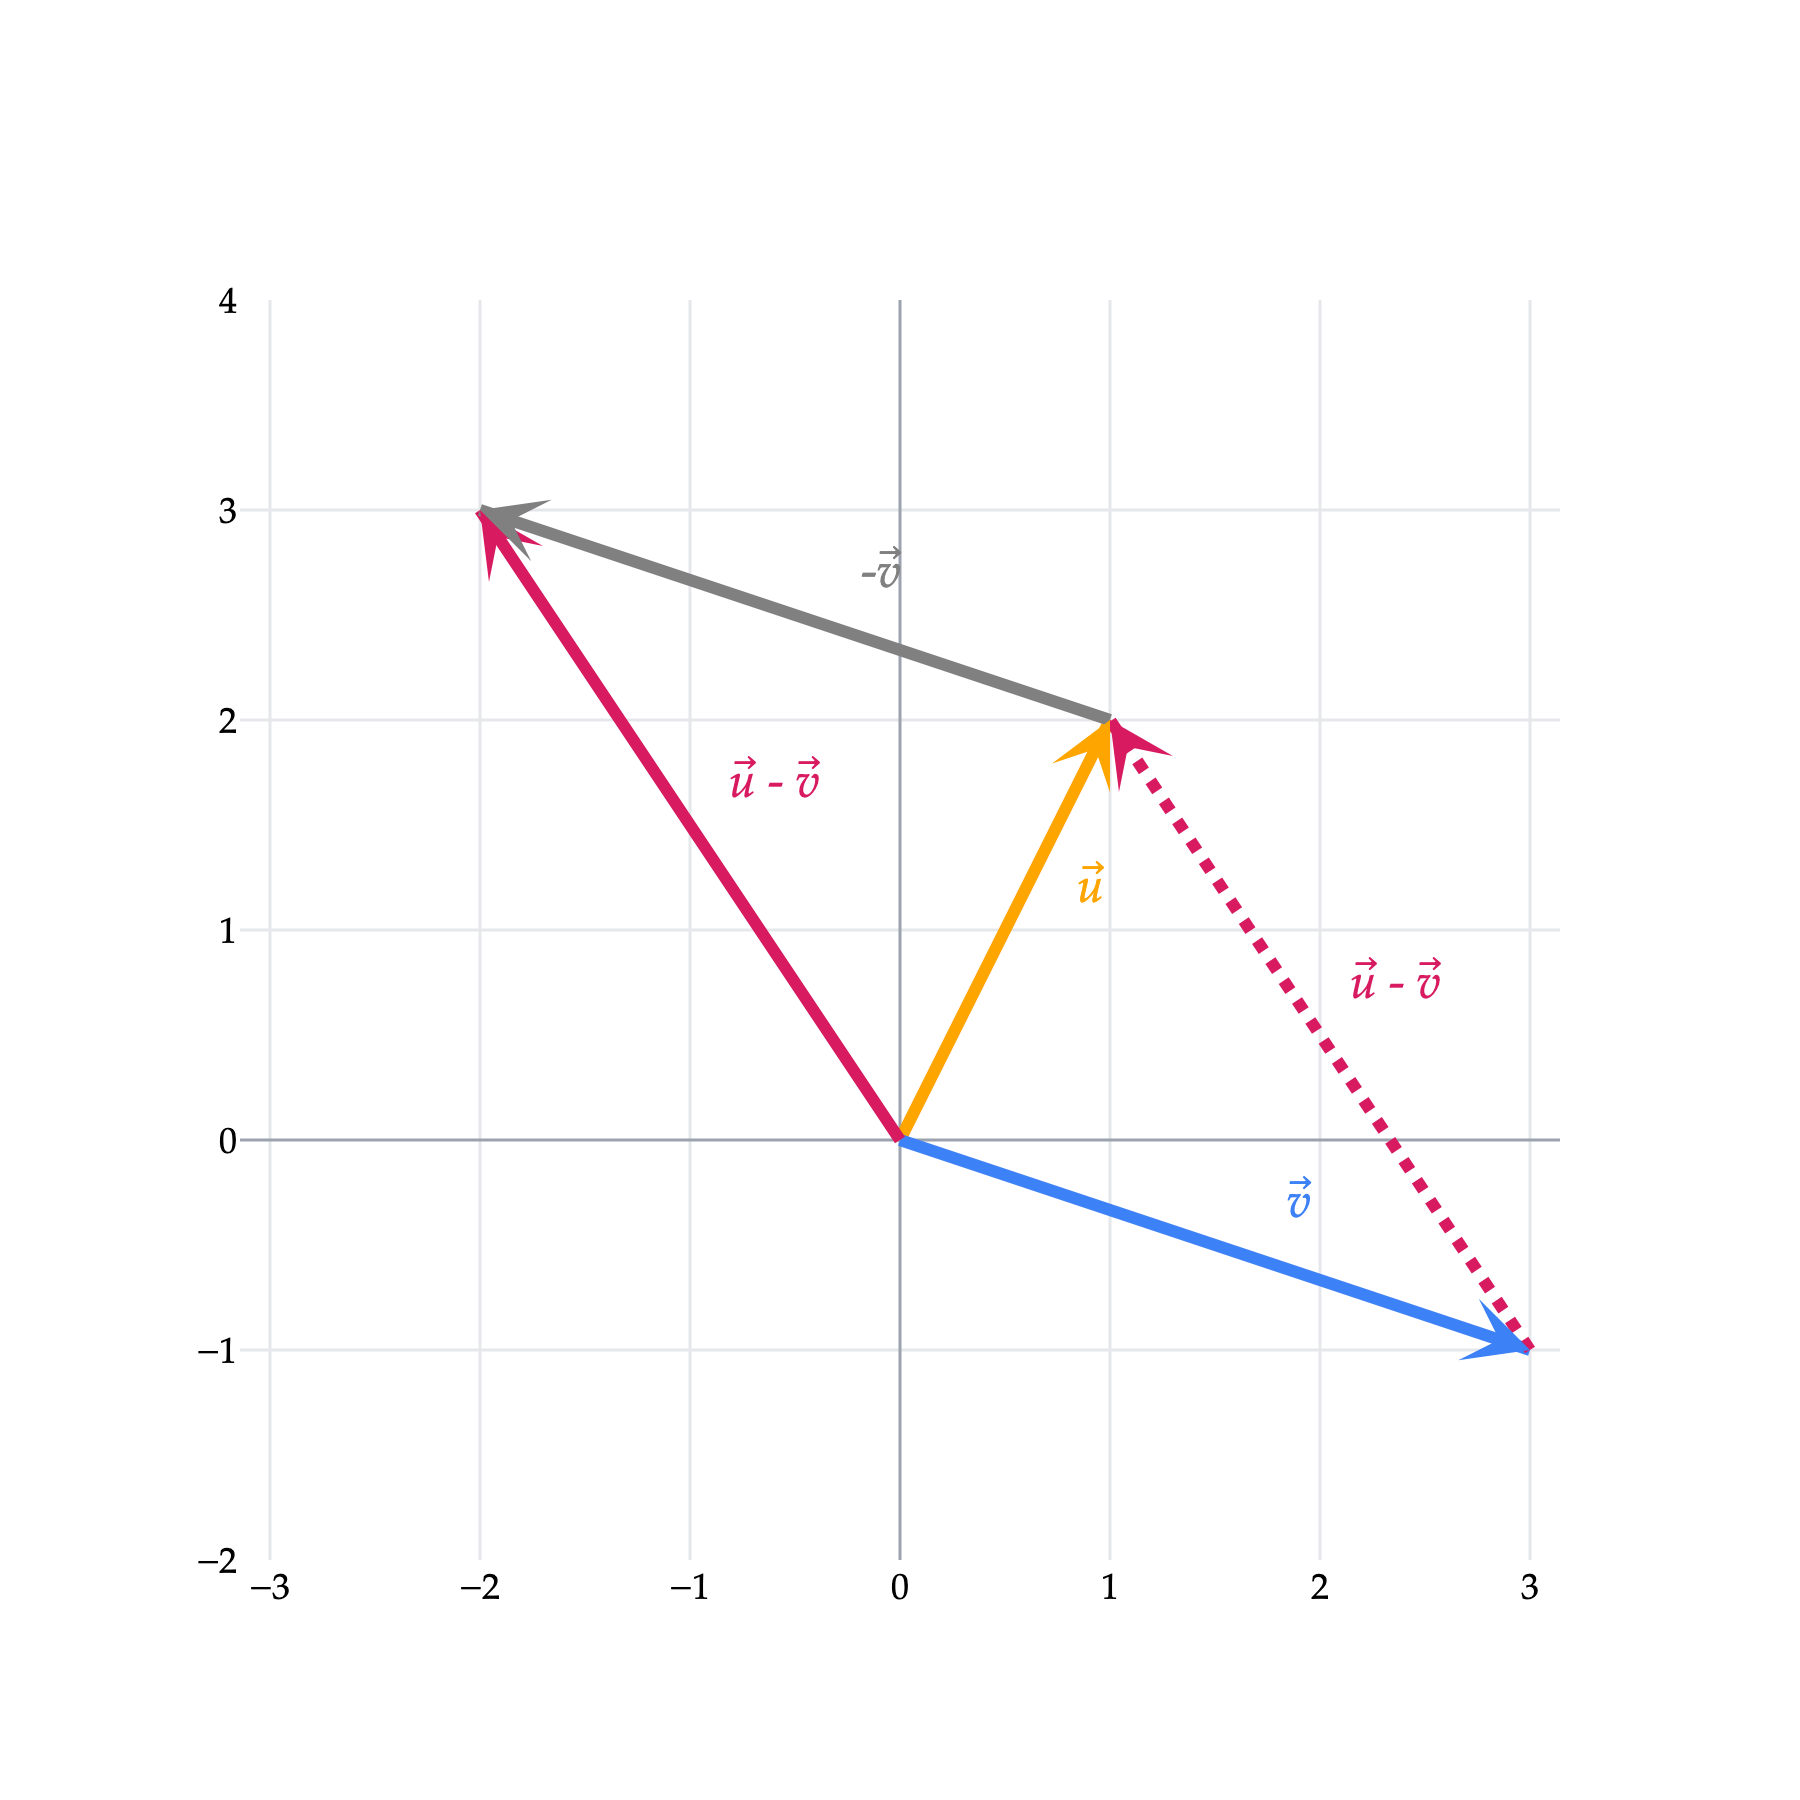

In [13]:
vectors = [
    (((0, 0), (1, 2)), 'orange', '<i>u</i>\u20D7'),
    (((0, 0), (3, -1)), '#3d81f6', '<i>v</i>\u20D7'),
    (((0, 0), (1 - 3, 2 - (-1))), '#d81a60', '<i>u</i>\u20D7 - <i>v</i>\u20D7'),
    (((1, 2), (1 - 3, 2 - (-1))), 'gray', '-<i>v</i>\u20D7'),  # -v from tip of u to u - v
    (((3, -1), (1, 2)), '#d81a60', None),  # u-v from the tip of v to the tip of u
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.2)

fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-3, 3], tickvals=np.arange(-3, 4))
fig.update_yaxes(range=[-2, 4], tickvals=np.arange(-2, 5))

_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig,
    vectors,
    {
        0: "orange",
        1: "#3d81f6",
        2: "#d81a60",
        3: "gray",
        4: "#d81a60",
    }
)

# Show the translated copy of u-v as a dotted arrow from v to u.
fig.data[4].line.dash = "dot"
dotted_direction = np.array([1, 2]) - np.array([3, -1])
dotted_direction = dotted_direction / np.linalg.norm(dotted_direction)
fig.layout.annotations[-1].ax = 1 - 0.25 * dotted_direction[0]
fig.layout.annotations[-1].ay = 2 - 0.25 * dotted_direction[1]
fig.add_annotation(
    x=2.35, y=0.75, text='<i>u</i>\u20D7 - <i>v</i>\u20D7',
    showarrow=False, font=dict(color="#d81a60", size=16),
)
fig.show(scale=3)

Notice that $\color{#d81a60} \vec u - \vec v$ is also the vector that results from drawing an arrow from the tip of $\color{#3d81f6} \vec v$ to the tip of $\color{orange} \vec u$, when **both** $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ are drawn at the origin! This is why we earlier described $\color{#d81a60} \vec u - \vec v$ as being one of the diagonals of the parallelogram formed by $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$.

### The zero vector

The previous example raises an important point: what happens when you subtract a vector from itself? Again, suppose $\color{#3d81f6} \vec v = \begin{bmatrix} 3 \\ -1 \end{bmatrix}$. Then,

$${\color{#3d81f6} \vec v} - {\color{#3d81f6} \vec v} = {\color{#3d81f6} \begin{bmatrix} 3 \\ -1 \end{bmatrix}} - {\color{#3d81f6} \begin{bmatrix} 3 \\ -1 \end{bmatrix}} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \vec 0.$$

A vector in which all components are equal to $0$ is called a **zero vector**, $\vec 0$. When we say "the" zero vector, the number of components in that zero vector is usually clear from the context. The zero vector has a length of $0$, and its direction is undefined: it looks like a point at the origin.

In [14]:
# Draw u, then v, then w so that the three displacements close the path.
vectors = [
    (((0, 0), (-2, 3)), "orange", "<i>u</i>\u20D7"),
    (((-2, 3), (2, 4)), "#3d81f6", "<i>v</i>\u20D7"),
    (((2, 4), (0, 0)), "#d81a60", "<i>w</i>\u20D7"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.3, vdeltay=0.25)
fig.update_layout(
    width=600, height=600,
    xaxis_title="$x$", yaxis_title="$y$", showlegend=False,
)
fig.update_xaxes(range=[-3, 3], dtick=1, scaleanchor="y")
fig.update_yaxes(range=[-1, 5], dtick=1)

_style_plotly(fig, renderer="png")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6", 2: "#d81a60"})
fig.write_image(_notes_root / "ch01" / "imgs" / "activity2-close-loop.png", scale=2)

:::{tip} Activity 2

For this activity, let

$$\vec u = \begin{bmatrix} -2 \\ 3 \end{bmatrix}, \qquad \vec v = \begin{bmatrix} 4 \\ 1 \end{bmatrix}. $$

1. Compute $\vec u + \vec v$.
1. Find a vector $\vec w$ such that $\vec u + \vec v + \vec w = \vec 0$.
1. Draw $\vec u$ at the origin, then $\vec v$ starting at the tip of $\vec u$, and then $\vec w$ starting at the tip of $\vec v$. What does $\vec w$ do geometrically?
1. Express $\vec w$ using $\vec u$, $\vec v$, addition, and scalar multiplication.

:::{tip} Solution
:class: dropdown

First,

$$\vec u + \vec v = \begin{bmatrix} -2 \\ 3 \end{bmatrix} + \begin{bmatrix} 4 \\ 1 \end{bmatrix} = \begin{bmatrix} 2 \\ 4 \end{bmatrix}. $$

Therefore,

$$\vec w = -\left(\vec u + \vec v\right) = \begin{bmatrix} -2 \\ -4 \end{bmatrix} = -\vec u - \vec v. $$

![The vectors u, v, and w drawn tip-to-tail to form a closed path.](imgs/activity2-close-loop.png)

When the vectors are drawn tip-to-tail, $\vec w$ returns from the tip of $\vec u + \vec v$ to the origin, closing the path. Thus,

$$\vec u + \vec v + \vec w = \vec 0.$$
:::

### Decomposition using basis vectors

Observe: every vector in $\mathbb{R}^2$ can be written as a sum of scalar multiples of two specific vectors: $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$. For example,

$${\color{#3d81f6} \vec v} = {\color{#3d81f6} \begin{bmatrix} 3 \\ -1 \end{bmatrix}} = {\color{#3d81f6} 3} \begin{bmatrix} 1 \\ 0 \end{bmatrix} + ({\color{#3d81f6} -1}) \begin{bmatrix} 0 \\ 1 \end{bmatrix}.$$

The vectors $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} 0 \\ 1 \end{bmatrix}$ have a special name: they are the **standard basis vectors** for $\mathbb{R}^2$. Think of them as the default **building blocks** that we use to express all other vectors with two components.

:::{note} Definition: Standard basis vectors
- There are two standard basis vectors in $\mathbb{R}^2$:

  $$\vec e_1 = \begin{bmatrix}1 \\ 0\end{bmatrix}, \qquad \vec e_2 = \begin{bmatrix}0 \\ 1\end{bmatrix}.$$

- There are three standard basis vectors in $\mathbb{R}^3$:

  $$\vec e_1 = \begin{bmatrix}1 \\ 0 \\ 0\end{bmatrix}, \qquad \vec e_2 = \begin{bmatrix}0 \\ 1 \\ 0\end{bmatrix}, \qquad \vec e_3 = \begin{bmatrix}0 \\ 0 \\ 1\end{bmatrix}.$$
:::

"Basis" has a formal definition that we will see later; the main idea for now is that the standard basis vectors in $\mathbb{R}^n$ can be used to express every **single vector** in $\mathbb{R}^n$, and furthermore, the way to express every vector is unique.

Let's focus on vectors in $\mathbb{R}^2$. For example, observe that
$$ \begin{bmatrix}2 \\ 3\end{bmatrix} 
= \begin{bmatrix}2 \\ 0\end{bmatrix} + \begin{bmatrix}0 \\ 3\end{bmatrix}
= 2\begin{bmatrix}1 \\ 0\end{bmatrix} + 3\begin{bmatrix}0 \\ 1\end{bmatrix} = 2\vec e_1 + 3\vec e_2.$$

This decomposition is unique, meaning that there is no other way to construct $\begin{bmatrix} 2 \\ 3 \end{bmatrix}$ using $\vec e_1$ and $\vec e_2$ as building blocks.

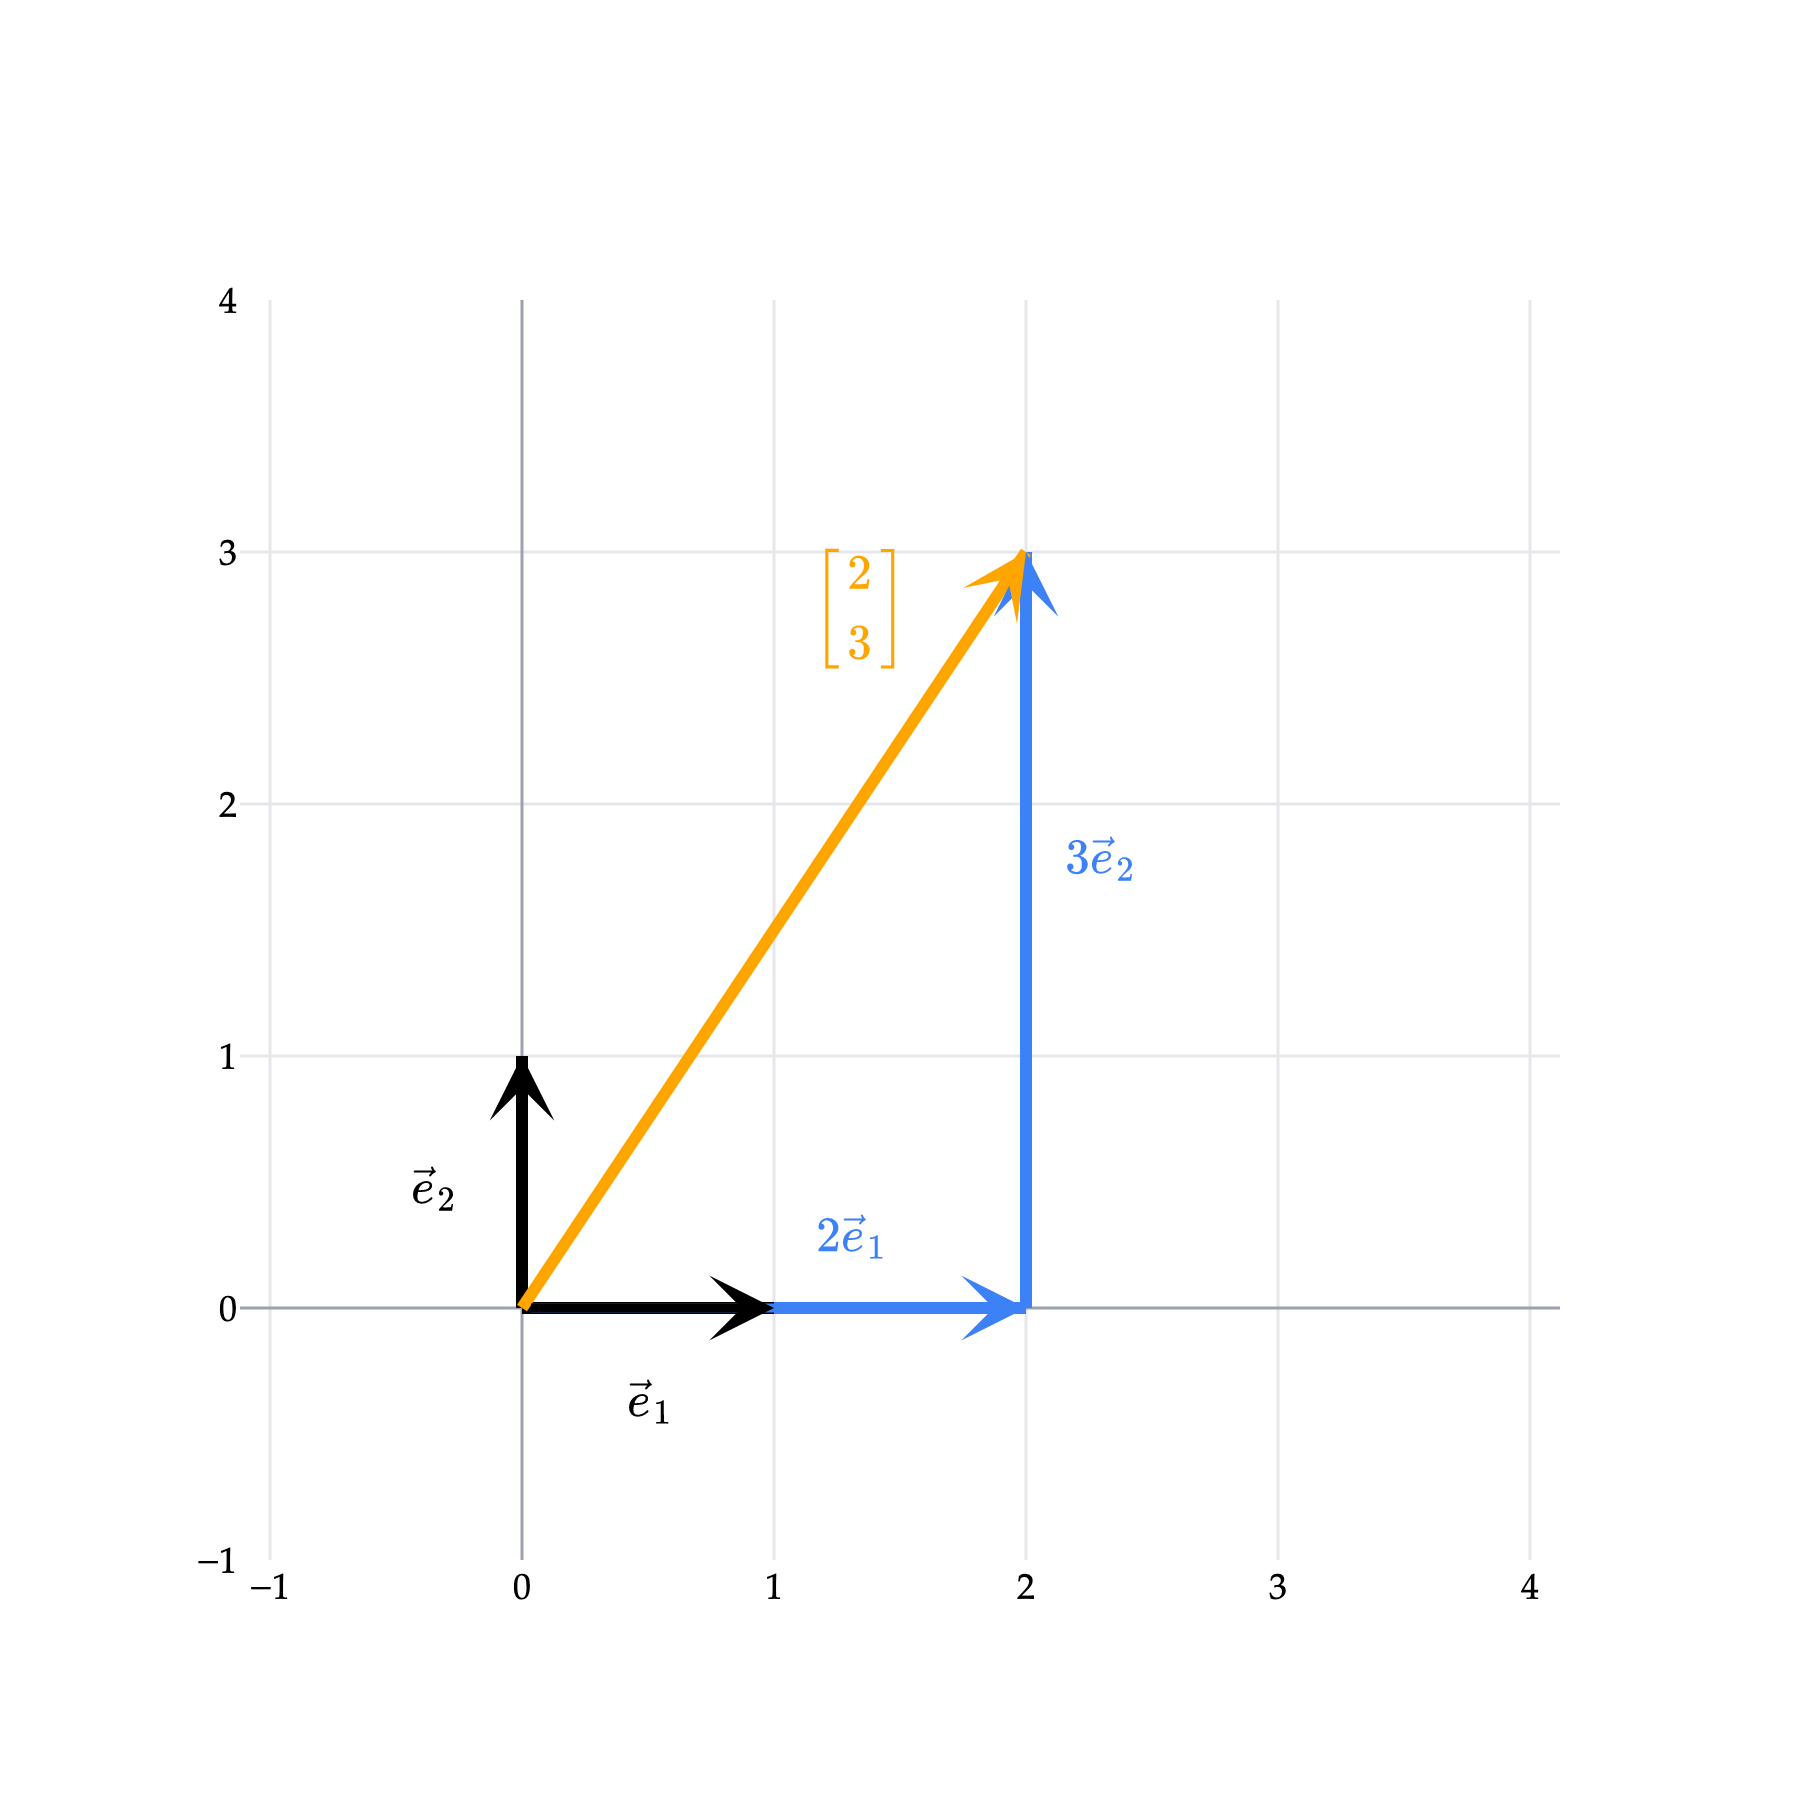

In [15]:
from IPython.display import display, HTML
import plotly.io as pio
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---

# Decompose [2, 3] into scaled copies of the standard basis vectors.
vectors = [
    (((0, 0), (2, 0)), "#3d81f6", r"$2\vec e_1$"),
    (((2, 0), (2, 3)), "#3d81f6", r"$3\vec e_2$"),
    (((0, 0), (1, 0)), "black", r"$\vec e_1$"),
    (((0, 0), (0, 1)), "black", r"$\vec e_2$"),
    (((0, 0), (2, 3)), "orange", r"$\begin{bmatrix}2 \\ 3\end{bmatrix}$"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.3, vdeltay=0.3)
fig.update_layout(width=600, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 4], dtick=1)
fig.update_yaxes(range=[-1, 4], dtick=1)

_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig, vectors,
    {0: "#3d81f6", 1: "#3d81f6", 2: "black", 3: "black", 4: "orange"},
)
fig.layout.annotations[5].x = 0.5
fig.layout.annotations[5].y = -0.35
fig.layout.annotations[7].x = -0.35
fig.layout.annotations[7].y = 0.5
# Move the [2, 3] annotation up by 1 unit on the y-axis
fig.layout.annotations[9].y += 1
fig.show(scale=3)

In effect, we are decomposing $\begin{bmatrix} 2 \\ 3 \end{bmatrix}$ as a sum of a vector parallel to the $x$-axis (a "horizontal" vector) and one parallel to the $y$-axis (a "vertical" vector).

The same principle holds in $\mathbb{R}^3$: any vector with three components can be decomposed as a sum of three vectors, one parallel to each of the $x$-, $y$-, and $z$-axes. For example,

$$\begin{bmatrix} 2 \\ 3 \\ -1 \end{bmatrix}
= \begin{bmatrix} 2 \\ 0 \\ 0 \end{bmatrix} + \begin{bmatrix} 0 \\ 3 \\ 0 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \\ -1 \end{bmatrix}
= 2\vec e_1 + 3\vec e_2 - \vec e_3.$$

In [16]:
# Decompose [2, 3, -1] into scaled copies of the standard basis vectors, showing only e's and the final vector.
vectors = [
    (((0, 0, 0), (1, 0, 0)), "black", "e<sub>1</sub>"),
    (((0, 0, 0), (0, 1, 0)), "black", "e<sub>2</sub>"),
    (((0, 0, 0), (0, 0, 1)), "black", "e<sub>3</sub>"),
    (((0, 0, 0), (2, 3, -1)), "orange", "[2, 3, -1]"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.18, vdeltay=0.18, vdeltaz=0.18)
_style_plotly(fig, renderer="plotly_mimetype")
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-2, 4], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        yaxis=dict(range=[-2, 5], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        zaxis=dict(range=[-2, 2], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        aspectmode="cube",
    ),
)

_set_vector_colors(
    fig, vectors,
    {
        0: "black", 1: "black", 2: "black", 3: "orange"
    },
)

# Draw faint coordinate axes through the origin.
axis_segments = [
    ([-2, 4], [0, 0], [0, 0]),
    ([0, 0], [-2, 5], [0, 0]),
    ([0, 0], [0, 0], [-2, 2]),
]
for x, y, z in axis_segments:
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="lines",
        line=dict(color="#f0f0f0", width=3), opacity=0.85,
        hoverinfo="skip", showlegend=False,
    ))

# Keep the vectors visually on top of the coordinate axes.
fig.data = fig.data[-3:] + fig.data[:-3]
fig.show()

Note: the plot above shows the vector $\begin{bmatrix} 2 \\ 3 \\ -1 \end{bmatrix}$ written horizontally; this is just due to a limitation in the plotting system, and it is not meant to be written horizontally.

Why would we ever need to break a vector into its components this way? The decomposition tells us how much of the vector lies in each coordinate direction, which lets us analyze or change those directions separately. 
- In physics, for example, we can split a force into horizontal and vertical components and apply Newton's laws along each axis.
- In data analysis, each basis direction can represent a different measured feature, allowing us to study the contribution of each feature separately.

In general, a vector $\vec v \in \mathbb{R}^n$ can be expressed as

$$\begin{bmatrix} v_1 \\ \vdots \\ v_n \end{bmatrix} = v_1 \vec e_1 + \cdots + v_n \vec e_n,$$

where $\vec e_1$ is the first standard basis vector in $\mathbb{R}^n$ – a vector with a $1$ at position $1$ and $0$'s in all other positions – $\vec e_2$ is the second standard basis vector, and so on.

### Linear combinations

We have now seen expressions of the form

$$3 \vec u - 4 \vec v,$$

$$\vec u - \vec v,$$

$$\vec u + \vec v + \vec w,$$

and

$$2\vec e_1 + 3\vec e_2.$$

All of these expressions are examples of **linear combinations**: each expression involves scaling and adding vectors together to create another vector. Think of the original vectors, such as $\vec u$ and $\vec v$ in the expression $3\vec u - 4\vec v$, as "building blocks." The scalars $3$ and $-4$ tell us how much of each building block to use. Adding the scaled vectors creates the new vector $3\vec u - 4\vec v$.

:::{note} Definition: Linear combination

Suppose ${\color{#3d81f6} \vec v_1}, {\color{#3d81f6} \vec v_2}, \ldots, {\color{#3d81f6} \vec v_k}$ are vectors in $\mathbb{R}^n$, and $a_1, a_2, \ldots, a_k$ are scalars, sometimes called coefficients. A **linear combination** of ${\color{#3d81f6} \vec v_1}, {\color{#3d81f6} \vec v_2}, \ldots, {\color{#3d81f6} \vec v_k}$ is any vector of the form

$$a_1 {\color{#3d81f6} \vec v_1} + a_2 {\color{#3d81f6} \vec v_2} + \cdots + a_k {\color{#3d81f6} \vec v_k}.$$
:::

We have used ${\color{#3d81f6} \vec v_1}, {\color{#3d81f6} \vec v_2}, \ldots, {\color{#3d81f6} \vec v_k}$ as placeholders to give a general formula for cases where we have an arbitrary number of vectors, not just two or three. Here, $k$ is the placeholder for the number of vectors we have. In concrete examples, we may label our vectors $\vec v_1, \vec v_2, \ldots$ or simply $\vec u, \vec v$. These are all just symbols. The important thing to look for is whether $\vec v$ has the vector arrow on top: $\vec v_1$ is a vector, but $v_1$ is a scalar.

Using the vectors from above,

$${\color{orange} \vec u} = {\color{orange} \begin{bmatrix} 1 \\ 2 \end{bmatrix}}, \quad {\color{#3d81f6} \vec v} = {\color{#3d81f6} \begin{bmatrix} 3 \\ -1 \end{bmatrix}},$$

the vector ${\color{orange} 3 \vec u} - {\color{#3d81f6} 4 \vec v}$ is

$${\color{orange} 3\vec u} - {\color{#3d81f6}  4\vec v} = 3{\color{orange}\begin{bmatrix} 1 \\ 2 \end{bmatrix}} - 4{\color{#3d81f6}\begin{bmatrix} 3 \\ -1 \end{bmatrix}} = \begin{bmatrix} 3 \\ 6 \end{bmatrix} + \begin{bmatrix} -12 \\ 4 \end{bmatrix} = \begin{bmatrix} -9 \\ 10 \end{bmatrix}.$$

Visually,

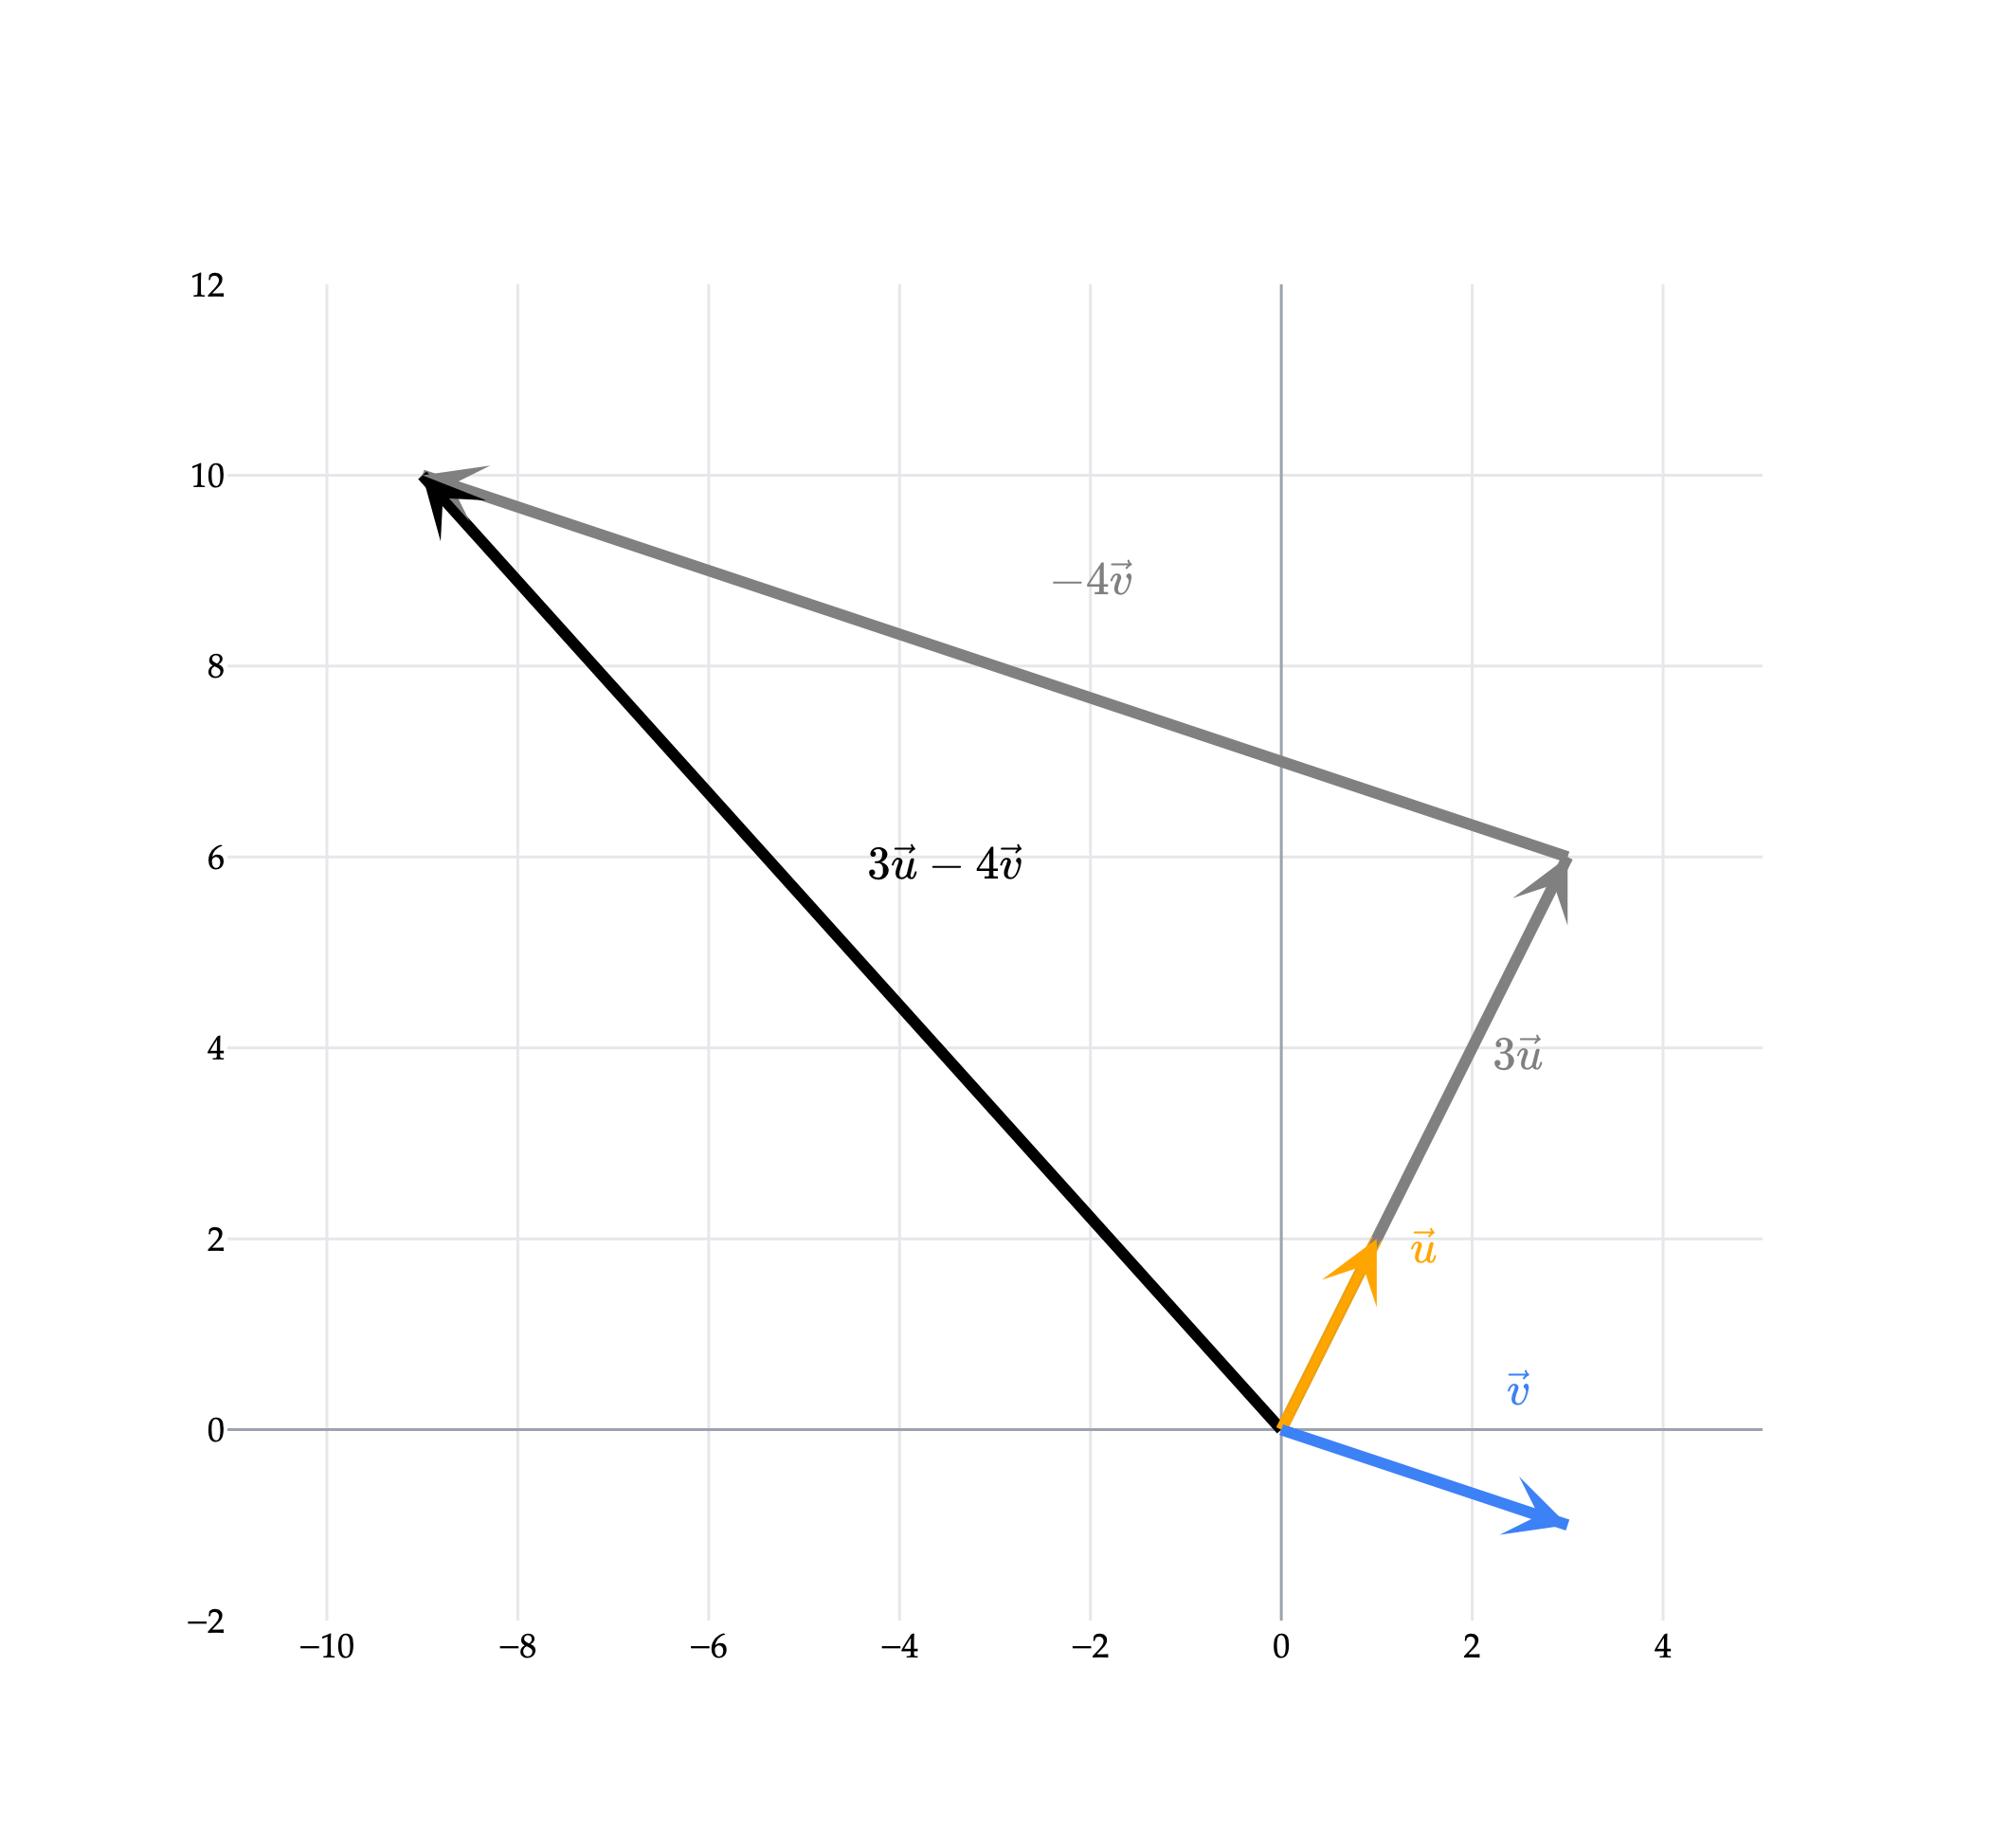

In [17]:
# Show u and v, then construct 3u - 4v tip-to-tail.
vectors = [
    (((0, 0), (3, 6)), "gray", r"$3\vec u$"),
    (((3, 6), (-9, 10)), "gray", r"$-4\vec v$"),
    (((0, 0), (-9, 10)), "black", r"$3\vec u - 4\vec v$"),
    (((0, 0), (1, 2)), "orange", r"$\vec u$"),
    (((0, 0), (3, -1)), "#3d81f6", r"$\vec v$"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=1, vdeltay=1)
fig.update_layout(width=700, height=650, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-11, 5], dtick=2)
fig.update_yaxes(range=[-2, 12], dtick=2)
_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig, vectors,
    {0: "gray", 1: "gray", 2: "black", 3: "orange", 4: "#3d81f6"},
)
fig.show(scale=3)

In [18]:
# Create the solution figure for Activity 3.
vectors = [
    (((0, 0), (6, 12)), "gray", r"$6\vec u$"),
    (((6, 12), (21, 7)), "gray", r"$5\vec v$"),
    (((0, 0), (21, 7)), "black", r"$6\vec u + 5\vec v$"),
    (((0, 0), (1, 2)), "orange", r"$\vec u$"),
    (((0, 0), (3, -1)), "#3d81f6", r"$\vec v$"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=1, vdeltay=1)
fig.update_layout(width=800, height=600, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-2, 23], dtick=5)
fig.update_yaxes(range=[-3, 14], dtick=5)
_style_plotly(fig, renderer="png")
_set_vector_colors(
    fig, vectors,
    {0: "gray", 1: "gray", 2: "black", 3: "orange", 4: "#3d81f6"},
)
fig.write_image(_notes_root / "ch01" / "imgs" / "activity3-linear-combination.png", scale=2)

:::{tip} Activity 3

Continue using

$${\color{orange} \vec u} = {\color{orange} \begin{bmatrix} 1 \\ 2 \end{bmatrix}} \qquad \text{and} \qquad {\color{#3d81f6} \vec v} = {\color{#3d81f6} \begin{bmatrix} 3 \\ -1 \end{bmatrix}}.$$

1. Compute ${\color{orange} 6\vec u} + {\color{#3d81f6} 5\vec v}$.
1. Visualize ${\color{orange} 6\vec u} + {\color{#3d81f6} 5\vec v}$ using tip-to-tail addition. Your diagram should include $\vec u$ and $\vec v$, the scaled vectors $6\vec u$ and $5\vec v$, and the resulting vector $6\vec u + 5\vec v$.

:::{tip} Solution
:class: dropdown

Algebraically,

$${\color{orange} 6\vec u} + {\color{#3d81f6} 5\vec v} = 6{\color{orange}\begin{bmatrix} 1 \\ 2 \end{bmatrix}} + 5{\color{#3d81f6}\begin{bmatrix} 3 \\ -1 \end{bmatrix}} = \begin{bmatrix} 6 \\ 12 \end{bmatrix} + \begin{bmatrix} 15 \\ -5 \end{bmatrix} = \begin{bmatrix} 21 \\ 7 \end{bmatrix}.$$

![The vectors u and v together with a tip-to-tail construction of 6u plus 5v.](imgs/activity3-linear-combination.png)

The gray vectors show $6\vec u$ followed by $5\vec v$. The black vector from the origin to their final endpoint is $6\vec u + 5\vec v$.
:::


The type of question we will start asking is, **"Can this vector be made out of a linear combination of these other vectors?"** The answer is not always yes!

For example, suppose

$$\vec u = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} \qquad \text{and} \qquad \vec v = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}.$$

Every linear combination of $\vec u$ and $\vec v$ has the form

$$a\vec u + b\vec v = \begin{bmatrix} a \\ b \\ 0 \end{bmatrix}.$$

No matter how hard we try, the last component will always be zero. Therefore, no linear combination of $\vec u$ and $\vec v$ can reach $\begin{bmatrix} -1 \\ 2 \\ 1 \end{bmatrix}$, or any other vector in $\mathbb{R}^3$ whose last component is nonzero.


In [19]:
# Compare u and v with a vector they cannot reach.
vectors = [
    (((0, 0, 0), (1, 0, 0)), "orange", "u"),
    (((0, 0, 0), (0, 1, 0)), "#3d81f6", "v"),
    (((0, 0, 0), (-1, 2, 1)), "#d81a60", "[-1, 2, 1]"),
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.18, vdeltay=0.18, vdeltaz=0.18)
_style_plotly(fig, renderer="plotly_mimetype")
_set_vector_colors(fig, vectors, {0: "orange", 1: "#3d81f6", 2: "#d81a60"})

# Draw the coordinate axes through the origin.
axis_segments = [
    ([-1.5, 1.5], [0, 0], [0, 0]),
    ([0, 0], [-0.5, 2.5], [0, 0]),
    ([0, 0], [0, 0], [-0.5, 2.5]),
]
for x, y, z in axis_segments:
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="lines",
        line=dict(color="#f0f0f0", width=3), opacity=0.55,
        hoverinfo="skip", showlegend=False,
    ))

# Keep the vectors visually on top of the coordinate axes.
fig.data = fig.data[-3:] + fig.data[:-3]
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-1.5, 1.5], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        yaxis=dict(range=[-0.5, 2.5], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        zaxis=dict(range=[-0.5, 2.5], dtick=1, gridcolor="#f0f0f0", linecolor="#f0f0f0"),
        aspectmode="cube",
        camera=dict(eye=dict(x=1.45, y=1.45, z=1.15)),
    ),
)
fig.show()

:::{tip} Activity 4

Let

$$\vec u = \begin{bmatrix} 1 \\ 2 \end{bmatrix}, \qquad \vec v = \begin{bmatrix} 3 \\ -1 \end{bmatrix}, \qquad \vec w = \begin{bmatrix} 2 \\ 11 \end{bmatrix}.$$

1. Compute $2(\vec u + \vec v)$.
1. Compute $2\vec u + 2\vec v$. Are your answers the same? What does this tell you about how scalar multiplication distributes over vector addition?
1. Find scalars $a$ and $b$ such that $a\vec u + b\vec v = \vec w$. In other words, find a linear combination of $\vec u$ and $\vec v$ that equals $\vec w$.

:::{tip} Solution
:class: dropdown

First,

$$2(\vec u + \vec v) = 2\left(\begin{bmatrix} 1 \\ 2 \end{bmatrix} + \begin{bmatrix} 3 \\ -1 \end{bmatrix}\right) = 2\begin{bmatrix} 4 \\ 1 \end{bmatrix} = \begin{bmatrix} 8 \\ 2 \end{bmatrix}.$$

Also,

$$2\vec u + 2\vec v = 2\begin{bmatrix} 1 \\ 2 \end{bmatrix} + 2\begin{bmatrix} 3 \\ -1 \end{bmatrix} = \begin{bmatrix} 2 \\ 4 \end{bmatrix} + \begin{bmatrix} 6 \\ -2 \end{bmatrix} = \begin{bmatrix} 8 \\ 2 \end{bmatrix}.$$

The answers are the same. This illustrates the **distributive property**

$$c(\vec u + \vec v) = c\vec u + c\vec v.$$

To find $a$ and $b$, we solve

$$a\begin{bmatrix} 1 \\ 2 \end{bmatrix} + b\begin{bmatrix} 3 \\ -1 \end{bmatrix} = \begin{bmatrix} 2 \\ 11 \end{bmatrix}.$$

Two vectors are equal if and only if their corresponding components are equal. Therefore, matching components gives the system

$$\begin{aligned} a+3b &= 2, \\ 2a-b &= 11. \end{aligned}$$

The second equation gives $b=2a-11$. Substituting this into the first equation,

$$a+3(2a-11)=2 \quad \Longrightarrow \quad 7a=35 \quad \Longrightarrow \quad a=5.$$

Then

$$b=2(5)-11=-1.$$

Therefore,

$$\vec w = 5\vec u - \vec v.$$
:::

In Chapter 1.5, we will formally define the magnitude, or length, or a vector.
